# || NEMO PIPELINE Workstation  ||
© _Konstantinos Andreadis_ (Roux Lab & Salbreux Lab @UNIGE)

In [1]:
# Import custom scripts
from scripts import analysis, datahandler, visuals, simulation
from importlib import reload

for module in (analysis, datahandler, visuals, simulation):
    reload(module)

# Import python essentials
import os
import numpy as np
import matplotlib.pyplot as plt
import trimesh

# --Import Image--

Selected image path: /Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/sphere_defects.tif
>> Importing /Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/sphere_defects.tif...
Found 3D ZYX Hyperstack | (288, 3030, 3296) | 2876.22 MB !
Found xscale = 0.26000005720001257, yscale = 0.26000005720001257 !
Found zscale = 3.0 !
Found image scale = (3.0, 0.26000005720001257, 0.26000005720001257) !
>> Overwriting unit with um...
>> Selecting Z-Stack at T=0 C=0 ...
>> Reducing XY resolution by averaging 3 pixels...
Reduced shape = (288, 1010, 1098) | scale = (3.0, 0.7800001716000378, 0.7800001716000378) | size = 2555.09 MB !
Loaded T=0 C=0 Z-stack (2555.09 MB) !
>> Plotting slices...


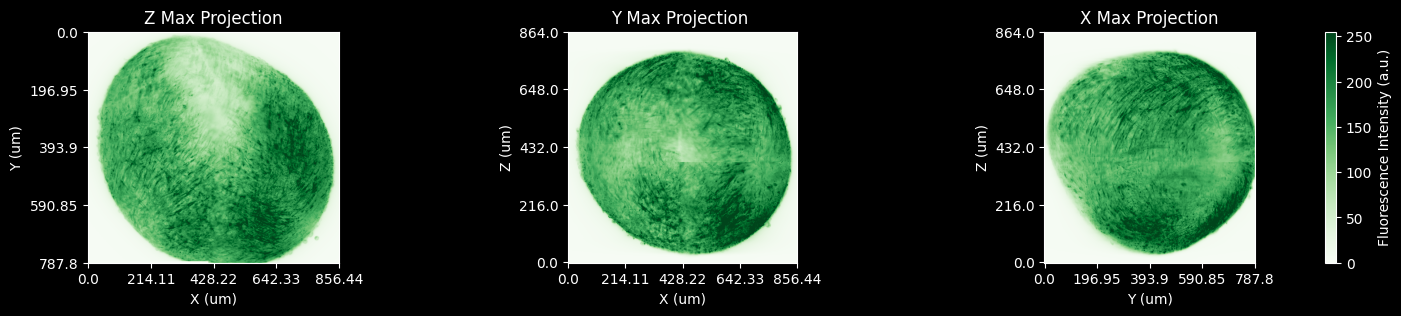

>> Plotting slices...


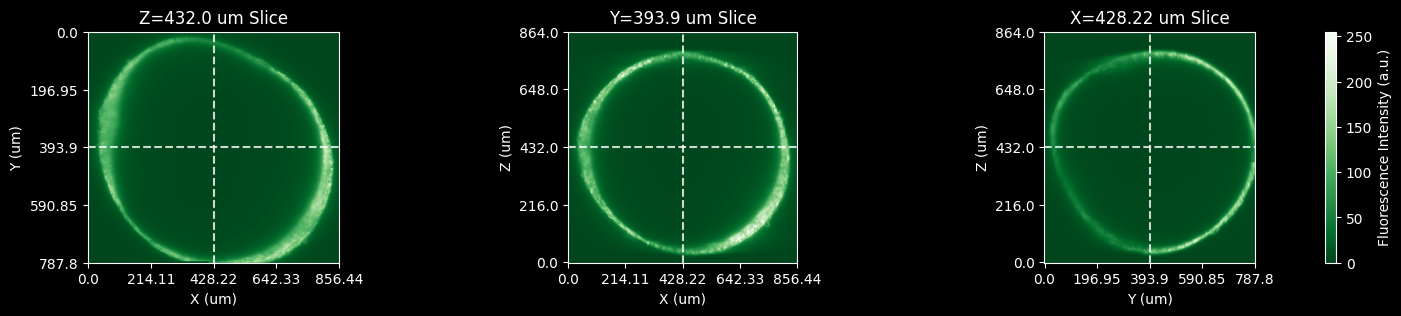

In [2]:
# ==== Choose Image ====
# [!] WINDOWS: Sometimes the r before the file path string is needed, no idea why.
img_path = r""
# img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/2pGPI_EXP1_25052025/48h/EXP1_GPI_48h_Pos1.tif"
# img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/2023/Live_nuclei/nuclei.tif"
# img_path = "/Users/andreadi/Downloads/Sph3-2-4-24--16-4-24-processed.tif"
# img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/DEBUG/debug.tiff"
# img_path = '/Users/andreadi/Downloads/For Claire DESSALLES/GUVs.tif'
# img_path = '/Users/andreadi/Downloads/For Claire DESSALLES/Droplet-_1.tif'
# img_path = '/Users/andreadi/Downloads/For Claire DESSALLES/Droplet-_2.tif'
img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/sphere_defects.tif"
print(f"Selected image path: {img_path}")

# ==== Choose Time Step and Channel ====
t_select = 0
c_select = 0

# ==== [Optional] Reduce Resolution ====
z_reduce_factor = 1  # 1 means no reduction
xy_reduce_factor = 1  # 1 means no reduction

# ==== [Optional] Normalise Intensities to [0, 1] ====
normalise_intensities = False  # can be set to False

# ==== [Optional] Overwrite Scaling with FIJI Values ====
custom_scaling = None  # please use (z, y, x)

# ==== [Optional] Overwrite unit with FIJI Values ====
custom_unit = "um"  # as string

# ==== Load Image ====
img_load = analysis.load_img_virtual(path=img_path, t_sel_idx=t_select,
                                     c_sel_idx=c_select, reduce_xy=xy_reduce_factor,
                                     reduce_z=z_reduce_factor, norm_vals=normalise_intensities,
                                     custom_scaling=custom_scaling,
                                     custom_unit=custom_unit)
if img_load is not None:
    img_raw, img_dim, img_scale, img_unit = img_load

    # ==== Create Folder Structure ====
    resdata_dir, resfig_dir = datahandler.create_resdirs(img_path)

    # ==== [Optional] Pad Image above & below Z/Y/X with 0s ====
    # z_pad = 10
    # img_raw = np.pad(img_raw, pad_width=((z_pad, z_pad), (0, 0), (0, 0)), mode='constant')
    # img_dim = img_raw.shape

    # ==== [Optional] Crop Image ====
    # img_raw = img_raw[:50, :, :]
    # img_dim = img_raw.shape

    # ==== Plot Image Slices and Max Projections ====
    visuals.plot_img(img=img_raw, scale=img_scale, unit=img_unit, max_proj=True, cmap='Greens',
                     savefig=os.path.join(resfig_dir, "sliced_maxproj_raw.png"))
    # z_i, y_i, x_i = int(200 / img_scale[0]), int(570 / img_scale[1]), int(455 / img_scale[2])
    z_i, y_i, x_i = int(img_dim[0] // 2), int(img_dim[1] // 2), int(img_dim[2] // 2)
    visuals.plot_img(img=img_raw, scale=img_scale, unit=img_unit, x_i=x_i, y_i=y_i, z_i=z_i,
                     savefig=os.path.join(resfig_dir, "sliced_raw.png"), cmap="Greens_r")

    # ==== 3D Render Image ====
    # visuals.view_img(img_list=[img_raw], title_list=["Raw Image"], scale=img_scale)
else:
    img_raw, img_dim, img_scale, img_unit = np.zeros((1, 1, 1)), (1, 1, 1), (1, 1, 1), "?"
    resdata_dir, resfig_dir = None, None

## Channel Composite Viewer

In [ ]:
# ==== Choose Image ====
t_select = 0
dims = analysis.load_img_dimensions(img_path)
num_channels = dims["C"]
channel_colors = ["Greens", "Reds", "Blues"]
channel_labels = ["Channel 1", "Channel 2", "Channel 3"]
composite_stack = []

for c_i in range(num_channels):
    # ==== Choose Time Step and Channel ====
    c_select = c_i

    # ==== Load Image ====
    img_load = analysis.load_img_virtual(path=img_path, t_sel_idx=t_select,
                                         c_sel_idx=c_select, reduce_xy=1, reduce_z=1, norm_vals=False,
                                         custom_scaling=None, custom_unit="um")
    img_raw_i, img_dim_i, img_scale_i, img_unit_i = img_load
    composite_stack.append(img_raw_i)

    # # ==== Plot Image Slices and Max Projections ====
    # visuals.plot_img(img=img_raw_i, scale=img_scale_i, unit=img_unit_i, max_proj=True, cmap=f"{channel_colors[c_i]}")
    # z_i, y_i, x_i = int(img_dim[0] // 2), int(img_dim[1] // 2), int(img_dim[2] // 2)
    # visuals.plot_img(img=img_raw_i, scale=img_scale_i, unit=img_unit_i, x_i=x_i, y_i=y_i, z_i=z_i,
    #                  cmap=f"{channel_colors[c_i]}_r")
# ==== 3D Render Image ====
visuals.view_img(img_list=composite_stack, title_list=channel_labels, color_list=[f"{i}_r" for i in channel_colors],
                 scale=img_scale, opacity_list=[0.8 for i in channel_colors])

# Create Mesh

## |1| Image Blur & Threshold

In [ ]:
# ==== Blur Image ====
sigma = 2
sigma_ = analysis.rescale_val_xyz(val=sigma, scale=img_scale)
img_blur = analysis.gaussian_blur(img=img_raw, sigma=sigma_, renorm=False)

# ==== Plot Image Slices ====
visuals.plot_img(img=img_blur, scale=img_scale, unit=img_unit, cmap="inferno",
                 savefig=os.path.join(resfig_dir, "sliced_blur.png"))

# ==== 3D Render Image ====
# visuals.view_img([img_blur], scale=img_scale, title_list=["Blurred Image"])

In [ ]:
# ==== Yen Threshold Image ====
# img_thresh_val = np.min([analysis.yen_thresh(img_blur[:, :, img_dim[2] // i]) for i in np.arange(2, 6)])
img_thresh_val = np.min(
    [analysis.yen_thresh(img_blur[:, :, img_dim[2] // 2]),
     analysis.yen_thresh(img_blur[:, img_dim[1] // 2, :]),
     analysis.yen_thresh(img_blur[img_dim[0] // 2, :, :])])
img_thresh_val *= 1.02

# img_thresh_val = np.min([analysis.yen_thresh(img_blur[:, :, int(img_dim[2] * i)]) for i in np.linspace(0.4, 0.6, 10)])

# ==== Binarise Image using Threshold ====
img_thresh = analysis.thresh_img(img_blur, img_thresh_val)

# ==== Plot Image Slices ====
visuals.plot_img(img=img_raw, scale=img_scale, unit=img_unit, savefig=os.path.join(resfig_dir, "sliced_thresh.png"),
                 cmap="inferno", thresh_mask=img_thresh)

# ==== 3D Render Image ====
# visuals.view_img([img_thresh], scale=img_scale, title_list=["Thresholded Image"])

In [ ]:
# # ==== [Optional] Fill Holes in Binary Image ====
# img_thresh = analysis.fill_holes_img(img_thresh)
#
# # ==== Plot Image Slices ====
# visuals.plot_img(img=img_raw, scale=img_scale, unit=img_unit,
#                  savefig=os.path.join(resfig_dir, "sliced_thresh.png"),
#                  cmap="inferno", thresh_mask=img_thresh)

In [ ]:
# # ==== [Optional] Save Thresholded Raw Image as .tiff ====
# visuals.view_img([img_raw, img_thresh], opacity_list=[1.0, 0.6], color_list=["green", "Blues"], scale=img_scale,
#                  title_list=["Raw Image", "Thresholded Image"])
# img_thresh = analysis.thresh_img(img_raw, img_thresh_val, keep_values_above=True)
# datahandler.save_tiff(img_thresh, filepath=os.path.join(resfig_dir, "thresh_img.tiff"))

## |2| Surface Mesh Extraction

In [ ]:
# ==== Segment Surface Mesh(es) ====
mcub_res = 2
full_mesh = analysis.marching_cubes(img=img_thresh, scale=img_scale, level=0.5, step_size=mcub_res)

# ==== Select INNER / OUTER Mesh ====
mesh_sel_mask = np.einsum('ij,ij->i', full_mesh.vertices - np.mean(full_mesh.vertices, axis=0),
                          full_mesh.vertex_normals) > 0

# ==== Select TOP / BOTTOM Mesh ====
# mesh_sel_mask = np.einsum('ij,ij->i', np.array([[1, 0, 0] for _ in range(len(full_mesh.vertices))]),
#                           full_mesh.vertex_normals) < 0

# ==== Apply Sub-Mesh Selection ====
inner_mesh = analysis.sel_submesh(mesh=full_mesh, mask=mesh_sel_mask)
outer_mesh = analysis.sel_submesh(mesh=full_mesh, mask=~mesh_sel_mask)

# ==== Save Mesh(es) ====
datahandler.save_mesh(full_mesh, os.path.join(resdata_dir, "full_mesh.ply"))
datahandler.save_mesh(inner_mesh, os.path.join(resdata_dir, "inner_mesh.ply"))
datahandler.save_mesh(outer_mesh, os.path.join(resdata_dir, "outer_mesh.ply"))
print(
    f"Number of vertices: #INNER = {inner_mesh.vertices.shape[0]} + #OUTER = {outer_mesh.vertices.shape[0]} == #FULL = {full_mesh.vertices.shape[0]}!")

# ==== Plot Image Slices with Mesh Overlay ====
visuals.plot_img(img=img_raw, scale=img_scale, unit=img_unit,
                 savefig=os.path.join(resfig_dir, "sliced_raw_full-mesh.png"), meshes=[inner_mesh, outer_mesh],
                 mesh_colors=["red", "blue"])

In [ ]:
# ==== 3D Render Mesh(es) ====
visuals.view_mesh(mesh_list=[full_mesh, inner_mesh], mesh_colors=["white", "red"],
                  mesh_titles=["Full Mesh", "Inner Mesh"], mesh_opacities=[0.3, 0.3], vec_freq=5,
                  img=img_raw, img_opacity=0.5, scale=img_scale)
# visuals.view_mesh(mesh_list=[inner_mesh, outer_mesh], mesh_colors=["red", "blue"],
#                   mesh_titles=["Inner Mesh", "Outer Mesh"], mesh_opacities=[0.3, 0.3], vec_freq=5,
#                   img=img_raw, img_opacity=0.5, scale=img_scale)
# visuals.view_mesh(mesh_list=[full_mesh], mesh_colors=["white"],
#                   mesh_titles=["Full Mesh"], mesh_opacities=[1.0], vec_freq=5,
#                   img=img_raw, img_opacity=0.9, scale=img_scale)

## |3| Mesh Processing

In [ ]:
# ==== Smooth Mesh(es) ====
smooth_factor = 0.001
smooth_iterations = 200
full_mesh_smooth = analysis.taubin_smooth_mesh(mesh=full_mesh, n_iter=smooth_iterations, pass_band=smooth_factor)
inner_mesh_smooth = analysis.taubin_smooth_mesh(mesh=inner_mesh, n_iter=smooth_iterations, pass_band=smooth_factor)
outer_mesh_smooth = analysis.taubin_smooth_mesh(mesh=outer_mesh, n_iter=smooth_iterations, pass_band=smooth_factor)

# ==== Sub-Sample Mesh(es) ====
# full_mesh_smooth = analysis.subdivide_mesh(mesh=full_mesh_smooth, max_edge=2)
# inner_mesh_smooth = analysis.subdivide_mesh(mesh=inner_mesh_smooth, max_edge=2)
# outer_mesh_smooth = analysis.subdivide_mesh(mesh=outer_mesh_smooth, max_edge=2)

# ==== Save Mesh(es) ====
datahandler.save_mesh(full_mesh_smooth, os.path.join(resdata_dir, "full_mesh_smooth.ply"))
datahandler.save_mesh(inner_mesh_smooth, os.path.join(resdata_dir, "inner_mesh_smooth.ply"))
datahandler.save_mesh(outer_mesh_smooth, os.path.join(resdata_dir, "outer_mesh_smooth.ply"))

# ==== Plot Image Slices with Mesh Overlay ====
visuals.plot_img(img=img_raw, scale=img_scale, unit=img_unit,
                 savefig=os.path.join(resfig_dir, "sliced_smooth_full-mesh.png"), meshes=[full_mesh, full_mesh_smooth],
                 mesh_colors=["black", "purple"])
visuals.plot_img(img=img_raw, scale=img_scale, unit=img_unit,
                 savefig=os.path.join(resfig_dir, "sliced_smooth_inner-mesh.png"),
                 meshes=[inner_mesh, inner_mesh_smooth], mesh_colors=["black", "red"])
visuals.plot_img(img=img_raw, scale=img_scale, unit=img_unit,
                 savefig=os.path.join(resfig_dir, "sliced_smooth_outer-mesh.png"),
                 meshes=[outer_mesh, outer_mesh_smooth], mesh_colors=["black", "blue"])

In [ ]:
# ==== 3D Render Mesh(es) ====
# visuals.view_mesh(mesh_list=[inner_mesh, inner_mesh_smooth], mesh_colors=["grey", "red"],
#                   mesh_titles=["Inner Mesh", "Smooth Inner Mesh"], mesh_opacities=[0.3, 0.3])
# visuals.view_mesh(mesh_list=[full_mesh, full_mesh_smooth], mesh_colors=["grey", "red"],
#                   mesh_titles=["Full Mesh", "Smooth Full Mesh"], mesh_opacities=[0.3, 0.3], img=img_raw,
#                   scale=img_scale)

visuals.view_mesh(mesh_list=[inner_mesh_smooth, outer_mesh_smooth], mesh_colors=["red", "blue"],
                  mesh_titles=["Smooth Inner Mesh", "Smooth Outer Mesh"], mesh_opacities=[0.3, 0.3], img=img_raw,
                  scale=img_scale)

# visuals.view_mesh(mesh_list=[full_mesh_smooth], mesh_colors=["white"],
#                   mesh_titles=["Smooth Full Mesh"], mesh_opacities=[1.0], vec_freq=5,
#                   img=img_raw, img_opacity=0.5, scale=img_scale)

## |4| EMBL Sphere Fit

In [ ]:
# mesh_to_fit = full_mesh_smooth.copy()
mesh_to_fit = outer_mesh_smooth.copy()
# mesh_to_fit = inner_mesh_smooth.copy()
# ==== Fit Sphere ====
sphere_params = analysis.fit_sphere(points=mesh_to_fit.vertices)
sphere_x0, sphere_y0, sphere_z0, sphere_radius = sphere_params
sphere_mesh = trimesh.creation.icosphere(radius=sphere_radius, subdivisions=8)
sphere_mesh.vertices += [sphere_x0, sphere_y0, sphere_z0]
datahandler.save_array(np.array(sphere_params)[:, np.newaxis].T, "sphere_fit", header="x,y,z,radius",
                       folderpath=resdata_dir)
# ==== Crop Sphere ====
seg_fit_crop_cap_angle = 99.0
print(f">> Cropping sphere to {seg_fit_crop_cap_angle} degrees cap...")
sphere_crop_mask = ((sphere_mesh.vertices[:, 0] - sphere_x0) / np.linalg.norm(
    sphere_mesh.vertices - [sphere_x0, sphere_y0, sphere_z0], axis=1)) >= np.cos(
    np.radians(seg_fit_crop_cap_angle))
sphere_mesh_cropped = analysis.sel_submesh(mesh=sphere_mesh, mask=sphere_crop_mask)
print(f"Num of sphere vertices: {sphere_mesh_cropped.vertices.shape[0]}")

# ==== Plot Image Slices with Mesh Overlay ====
visuals.plot_img(img=img_raw, scale=img_scale, unit=img_unit,
                 savefig=os.path.join(resfig_dir, "sliced_raw_sphere-fit.png"), cmap="Greens_r",
                 meshes=[sphere_mesh_cropped], mesh_alpha=1.0)

In [ ]:
# ==== 3D Render Mesh(es) ====
visuals.view_mesh([sphere_mesh], img=img_raw, scale=img_scale)

## |5| Save Sampling Mesh

In [ ]:
# ==== Select Sampling Mesh ====
# sampl_mesh = full_mesh_smooth.copy()
# sampl_mesh = sphere_mesh_cropped.copy()
# sampl_mesh = inner_mesh_smooth.copy()
sampl_mesh = outer_mesh_smooth.copy()

# ==== [Optional] Merge Meshes Instead ====
# mesh_merge_1 = datahandler.load_mesh(os.path.join(resdata_dir, "inner_mesh_smooth.ply"), recalc_normals=False)
# mesh_merge_2 = datahandler.load_mesh(os.path.join(resdata_dir, "outer_mesh_smooth.ply"), recalc_normals=False)
# mesh_merge_1.vertex_normals = -1 * mesh_merge_2.vertex_normals
# sampl_mesh = trimesh.util.concatenate([mesh_merge_1, mesh_merge_2])


# ==== Save Sampling Mesh ====
datahandler.save_mesh(sampl_mesh, os.path.join(resdata_dir, "sampling_mesh.ply"))

# ==== Plot Image Slices with Mesh Overlay ====
visuals.plot_img(img=img_raw, scale=img_scale, unit=img_unit,
                 savefig=os.path.join(resfig_dir, "sliced_raw_sampling-mesh.png"), meshes=[sampl_mesh])
print(f"Number of sampling points: {len(sampl_mesh.vertices)} !")

# ==== 3D Render Mesh(es) ====
# visuals.view_mesh(mesh_list=[sampl_mesh], mesh_titles=["Mesh"], mesh_colors=["white"], mesh_opacities=[0.4],
#                   img=img_raw, scale=img_scale, vec_freq=100, hide_vectors=True, vec_length=20)

# -- Load Mesh --

>> Loading mesh /Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/sphere_defects/data/sampling_mesh.ply...
>> Recomputing normals ...
Number of sampling vertices: 596867 !
>> Plotting slices...


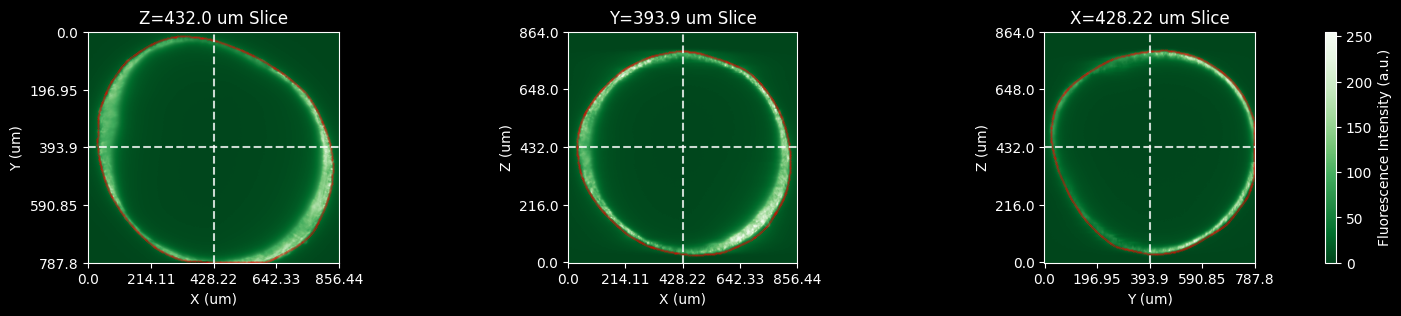

In [3]:
# ==== Load Sampling Mesh ====
# sampl_mesh = datahandler.load_mesh(os.path.join(resdata_dir, "full_mesh_smooth.ply"), recalc_normals=True, clean=False)
sampl_mesh = datahandler.load_mesh(os.path.join(resdata_dir, "sampling_mesh.ply"), recalc_normals=True, clean=False)
print(f"Number of sampling vertices: {len(sampl_mesh.vertices)} !")
# # sampl_mesh.show()

# ==== Plot Image Slices with Mesh Overlay ====
visuals.plot_img(img=img_raw, scale=img_scale, unit=img_unit, meshes=[sampl_mesh], slice_depth=1,
                 savefig=os.path.join(resfig_dir, "sliced_raw_sampling-mesh.png"))

# ==== Plot Half Max Projection Views ====
# visuals.plot_maxproj_pts(verts=sampl_mesh.vertices, unit=img_unit, cmap="Greys",
#                          savefig=os.path.join(resfig_dir, "maxproj_sampling-mesh.png"), hexsize=100, figsize=(12, 5))
# ==== 3D Render Mesh(es) ====
# visuals.view_mesh(mesh_list=[sampl_mesh], mesh_titles=["Mesh"], mesh_colors=["white"], mesh_opacities=[0.4],
#                   img=img_raw, scale=img_scale, vec_freq=400, hide_vectors=True, vec_length=20)
# visuals.view_mesh(mesh_list=[sampl_mesh], mesh_titles=["Mesh"], mesh_colors=["white"], mesh_opacities=[1.0],
#                   img=img_raw, scale=img_scale, vec_freq=100, hide_vectors=False, vec_length=10, vec_edge_width=0.1)

# Mesh Analysis

## |1| Inter-Mesh Distance/Thickness

>> Loading mesh /Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/sphere_defects/data/inner_mesh_smooth.ply...
>> Loading mesh /Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/sphere_defects/data/outer_mesh_smooth.ply...
>> Plotting slices...


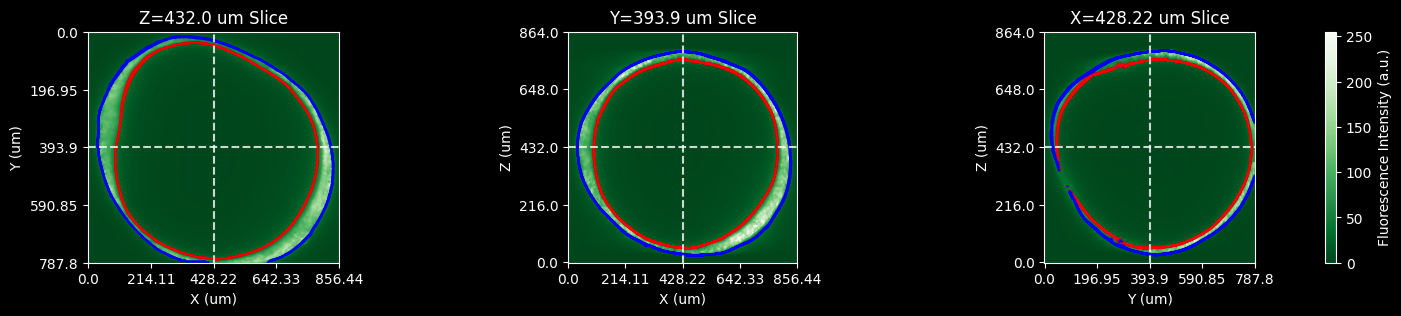

In [132]:
# ==== Select Mesh(es) ====
mesh_1 = datahandler.load_mesh(os.path.join(resdata_dir, "inner_mesh_smooth.ply"), recalc_normals=False)
mesh_2 = datahandler.load_mesh(os.path.join(resdata_dir, "outer_mesh_smooth.ply"), recalc_normals=False)
mesh_2.vertex_normals = -1 * mesh_2.vertex_normals

# ==== Plot Image Slices with Mesh Overlay ====
visuals.plot_img(img=img_raw, scale=img_scale, unit=img_unit, meshes=[mesh_1, mesh_2],
                 mesh_colors=["red", "blue"])

# ==== 3D Render Mesh(es) ====
# visuals.view_mesh(mesh_list=[mesh_1, mesh_2],
#                   mesh_colors=["Green", "Red"],
#                   mesh_titles=["MESH 1", "MESH 2"], img=img_raw, img_opacity=0.5, scale=img_scale)

>> Calculating distance between two meshes (509519, 613751) using 1000 samples...
AVG = 32.08454278569012 | MIN = 2.3405230236533487 | MAX = 80.01715849004839 | None? = 11
>> Interpolating 989 values on mesh of 509519 vertices with k = 10...
>> Saved /Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/sphere_defects/data/thickness.csv !


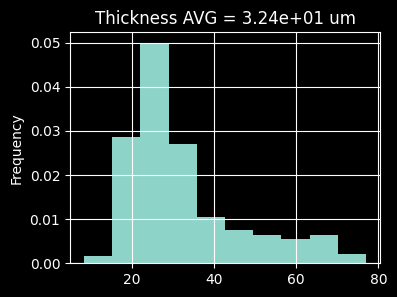

Plotting max projection of coloured points...


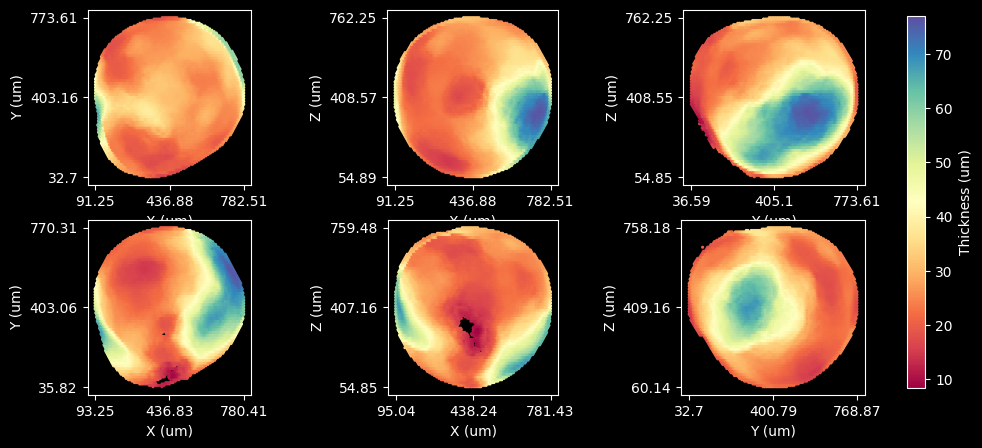

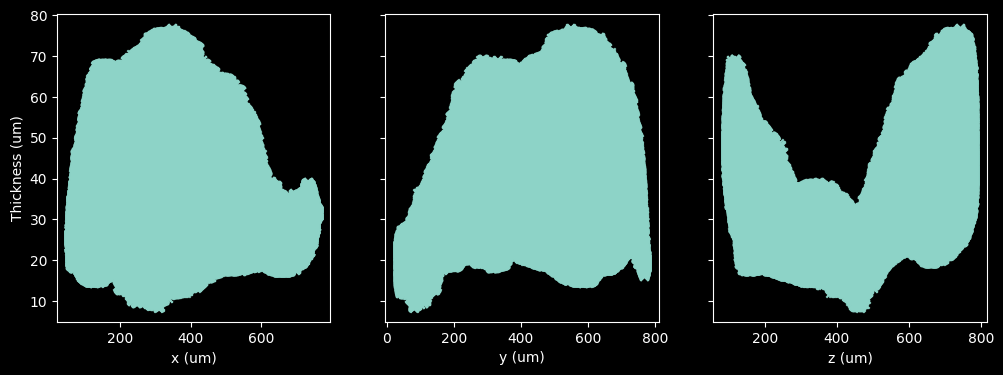

In [133]:
# ==== Calculate Inter-Mesh Distance ====
# thickness_crop_range = [0, 30]
thickness_crop_range = None
thickness_sampl_number = 1000

dist_vals, dist_idxs = analysis.inter_dist_mesh(mesh_1=mesh_1, mesh_2=mesh_2, num_sample=thickness_sampl_number,
                                                crop_range=thickness_crop_range, debug=True)
full_dist_vals = analysis.interpolate_on_mesh(mesh_1, dist_idxs, dist_vals, k=10)
# ==== Save Inter-Mesh Distance ====
datahandler.save_array(full_dist_vals, "thickness", header=f"dist ({img_unit})", folderpath=resdata_dir)

# ==== Plot Inter-Mesh Distance ====
visuals.plot_hist(array=full_dist_vals, title=f"Thickness AVG = {full_dist_vals.mean():.2e} {img_unit}",
                  xlim=thickness_crop_range,
                  savefig=os.path.join(resfig_dir, "thickness_hist.png"))
visuals.plot_maxproj_pts(verts=mesh_1.vertices, unit=img_unit, colors=full_dist_vals, cmap="Spectral",
                         hexsize=100, cmap_label=f"Thickness ({img_unit})",
                         savefig=os.path.join(resfig_dir, "thickness.png"), figsize=(12, 5))

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 4), sharey=True)
ax[0].scatter(mesh_1.vertices[:, 0], full_dist_vals, marker="x")
ax[1].scatter(mesh_1.vertices[:, 1], full_dist_vals, marker="x")
ax[2].scatter(mesh_1.vertices[:, 2], full_dist_vals, marker="x")
ax[0].set_xlabel(f"x ({img_unit})")
ax[1].set_xlabel(f"y ({img_unit})")
ax[2].set_xlabel(f"z ({img_unit})")
ax[0].set_ylabel(f"Thickness ({img_unit})")
plt.show()

In [134]:
# ==== 3D Render Result ====
visuals.view_colored_mesh_multiple([mesh_1, mesh_2],
                                   [visuals.color_scalar(full_dist_vals, normalise=True, cmap="coolwarm"),
                                    "white"], mesh_blending_list=["opaque", "translucent"],
                                   mesh_opacity_list=[1.0, 0.3])

>> Rendering colored mesh...


## |2| Gaussian & Mean Curvature

In [157]:
# ==== Define Crop Range of Gauss & Mean Curvature ====
gauss_exp = 1 / (np.ptp(mesh_1.vertices, axis=0).mean() / 2) ** 2
mean_exp = 1 / (np.ptp(mesh_1.vertices, axis=0).mean() / 2)
print(f"Gauss should be around {gauss_exp:.2e} (1/{img_unit}^2), "
      f"Mean should be around {mean_exp:.2e} (1/{img_unit})")
gauss_order_min, gauss_order_max = round(np.log10(gauss_exp)) - 1, round(np.log10(gauss_exp)) + 1
mean_order_min, mean_order_max = round(np.log10(mean_exp)) - 1, round(np.log10(mean_exp)) + 1
gauss_crop_range = [0.01 * 10 ** gauss_order_min, 10 ** gauss_order_max]
mean_crop_range = [0.01 * 10 ** mean_order_min, 10 ** mean_order_max]

# gauss_crop_range, mean_crop_range = None, None

# ==== Define Number of Random Calculation Selection ====
curvature_num_samples = 10000

# ==== Define Number of Nearest Neighbours to use for surface fit ====
curvature_k = 20

# ==== [Optional] Exclude Boundary Vertices ====
curvature_filter_boundary = False
curvature_filter_boundary_factor = 0.0  # exclude strength between 0 (max) and 1 (no exclusion)

Gauss should be around 7.86e-06 (1/um^2), Mean should be around 2.80e-03 (1/um)


### |2.1| Curvature Mesh #1

>> Calculating curvature for mesh with k=20 and for 20000/509519 vertices...
Gauss: AVG = -1.7051214512802435e-05 | MIN = -0.05992849249939301 | MAX = 0.006138734757373724 | None? = 0
Mean: AVG = 0.0027066442620212947 | MIN = -0.3693259984210703 | MAX = 0.1258507261782061 | None? = 0
>> Cropping Gauss to min 1e-08, max 0.0001...
Gauss: AVG = 9.684804775886115e-06 | MIN = 1.2336331695797484e-08 | MAX = 9.699828081571601e-05 | None? = 0
>> Cropping Mean to min 1.0000000000000002e-06, max 0.01...
Mean: AVG = 0.0029488440396357425 | MIN = 2.5824836585970016e-06 | MAX = 0.009896743869417678 | None? = 0
>> Interpolating 16769 values on mesh of 509519 vertices with k = 10...
>> Interpolating 18573 values on mesh of 509519 vertices with k = 10...
>> Saved /Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/sphere_defects/data/gauss_curv_1.csv !
>> Saved /Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/sphere_defec

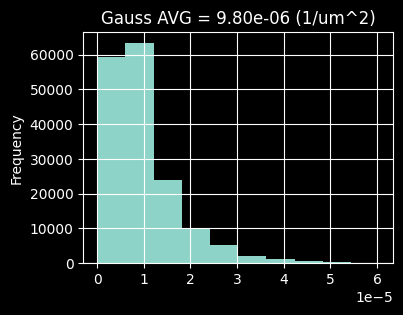

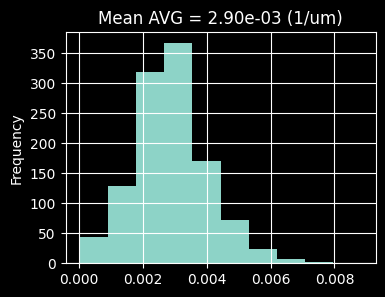

Plotting max projection of coloured points...


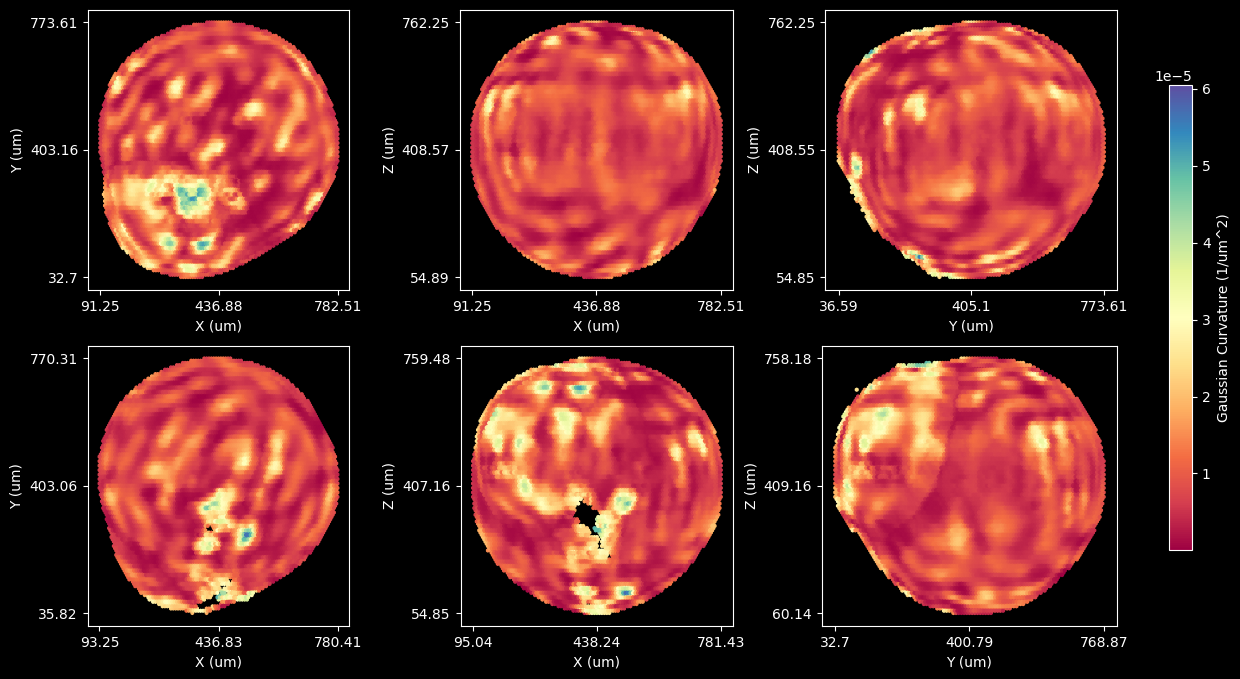

Plotting max projection of coloured points...


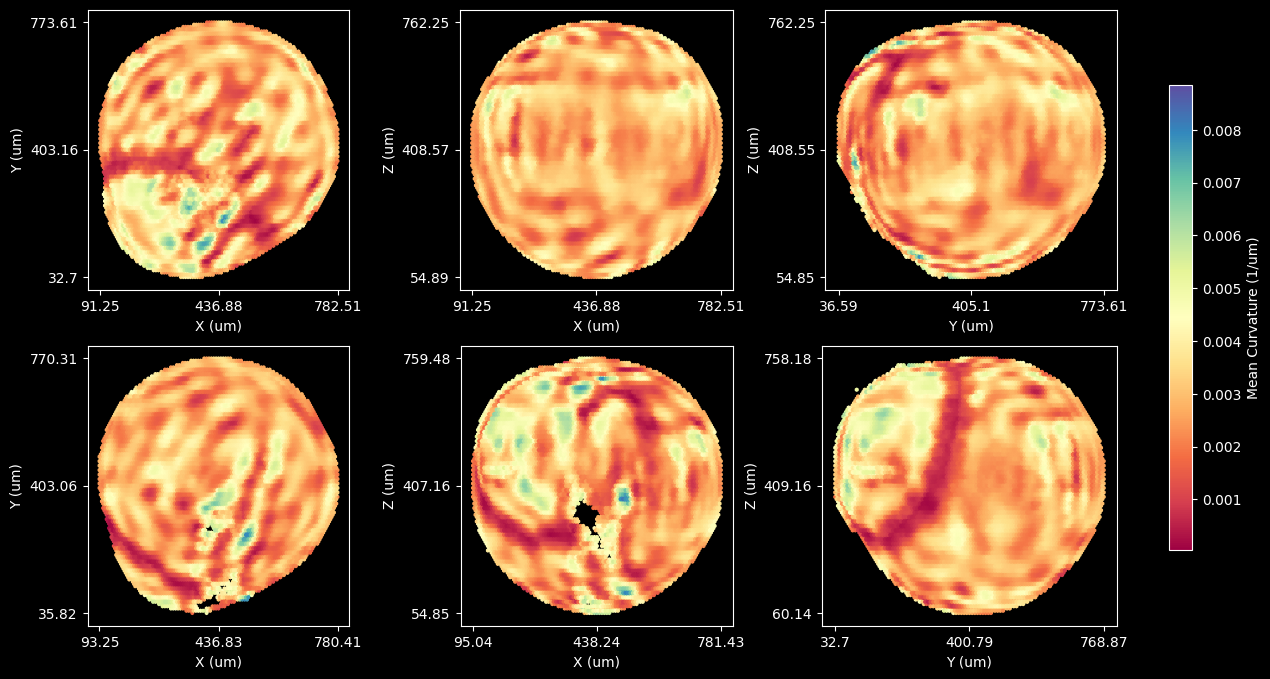

In [155]:
# ==== Calculate Gauss & Mean Curvature ====
curvature_results = analysis.curvature_by_srf_fit(mesh_1, num_sample=curvature_num_samples, k=curvature_k,
                                                  debug=True, filter_boundary=curvature_filter_boundary,
                                                  boundary_excl_factor=curvature_filter_boundary_factor,
                                                  gauss_crop_range=gauss_crop_range, mean_crop_range=mean_crop_range)

C_gauss, C_mean, C_gauss_idxs, C_mean_idxs = curvature_results
full_C_gauss_1 = analysis.interpolate_on_mesh(mesh_1, C_gauss_idxs, C_gauss, k=10)
full_C_mean_1 = analysis.interpolate_on_mesh(mesh_1, C_mean_idxs, C_mean, k=10)
# ==== Save Gauss & Mean Curvature ====
datahandler.save_array(full_C_gauss_1, "gauss_curv_1", header=f"gauss (1/{img_unit}^2)", folderpath=resdata_dir)
datahandler.save_array(full_C_mean_1, "mean_curv_1", header=f"mean (1/{img_unit})", folderpath=resdata_dir)

# ==== Plot Gauss & Mean Curvature ====
visuals.plot_hist(full_C_gauss_1, title=f"Gauss AVG = {full_C_gauss_1.mean():.2e} (1/{img_unit}^2)",
                  savefig=os.path.join(resfig_dir, "gauss_hist.png"))
visuals.plot_hist(full_C_mean_1, title=f"Mean AVG = {full_C_mean_1.mean():.2e} (1/{img_unit})",
                  savefig=os.path.join(resfig_dir, "mean_hist.png"))
visuals.plot_maxproj_pts(verts=mesh_1.vertices, unit=img_unit, colors=full_C_gauss_1, cmap="Spectral",
                         hexsize=100, cmap_label=f"Gaussian Curvature (1/{img_unit}^2)",
                         savefig=os.path.join(resfig_dir, "gauss_curv.png"))
visuals.plot_maxproj_pts(verts=mesh_1.vertices, unit=img_unit, colors=full_C_mean_1, cmap="Spectral",
                         hexsize=100, cmap_label=f"Mean Curvature (1/{img_unit})",
                         savefig=os.path.join(resfig_dir, "mean_curv.png"))

In [136]:
# ==== 3D Render Result ====
visuals.view_colored_mesh_multiple([mesh_1, mesh_1],
                                   [visuals.color_scalar(full_C_gauss_1, normalise=True, cmap="Spectral"),
                                    visuals.color_scalar(full_C_mean_1, normalise=True, cmap="Spectral")],
                                   name_list=["Gauss", "Mean"])

>> Rendering colored mesh...


### |2.1| Curvature Mesh #2

>> Calculating curvature for mesh with k=20 and for 10000/613751 vertices...
Gauss: AVG = -3.5563673292187956e-07 | MIN = -0.014015018319405966 | MAX = 0.003482436846322632 | None? = 0
Mean: AVG = 0.0025808226372866535 | MIN = -0.15451994838844174 | MAX = 0.07836161577187031 | None? = 0
>> Cropping Gauss to min 1e-08, max 0.0001...
Gauss: AVG = 7.851395186101176e-06 | MIN = 1.2309887969645535e-08 | MAX = 9.647945659428446e-05 | None? = 0
>> Cropping Mean to min 1.0000000000000002e-06, max 0.01...
Mean: AVG = 0.0026552179524875455 | MIN = 2.7662056638233946e-06 | MAX = 0.009876321789116852 | None? = 0
>> Interpolating 8347 values on mesh of 613751 vertices with k = 10...
>> Interpolating 9643 values on mesh of 613751 vertices with k = 10...
>> Saved /Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/sphere_defects/data/gauss_curv_2.csv !
>> Saved /Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/sphere_defe

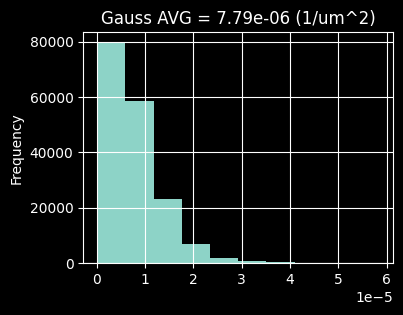

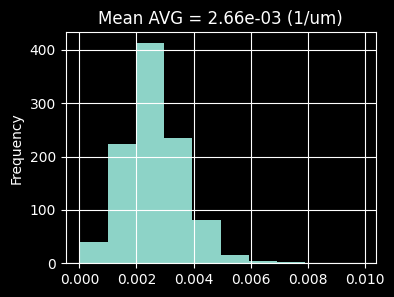

Plotting max projection of coloured points...


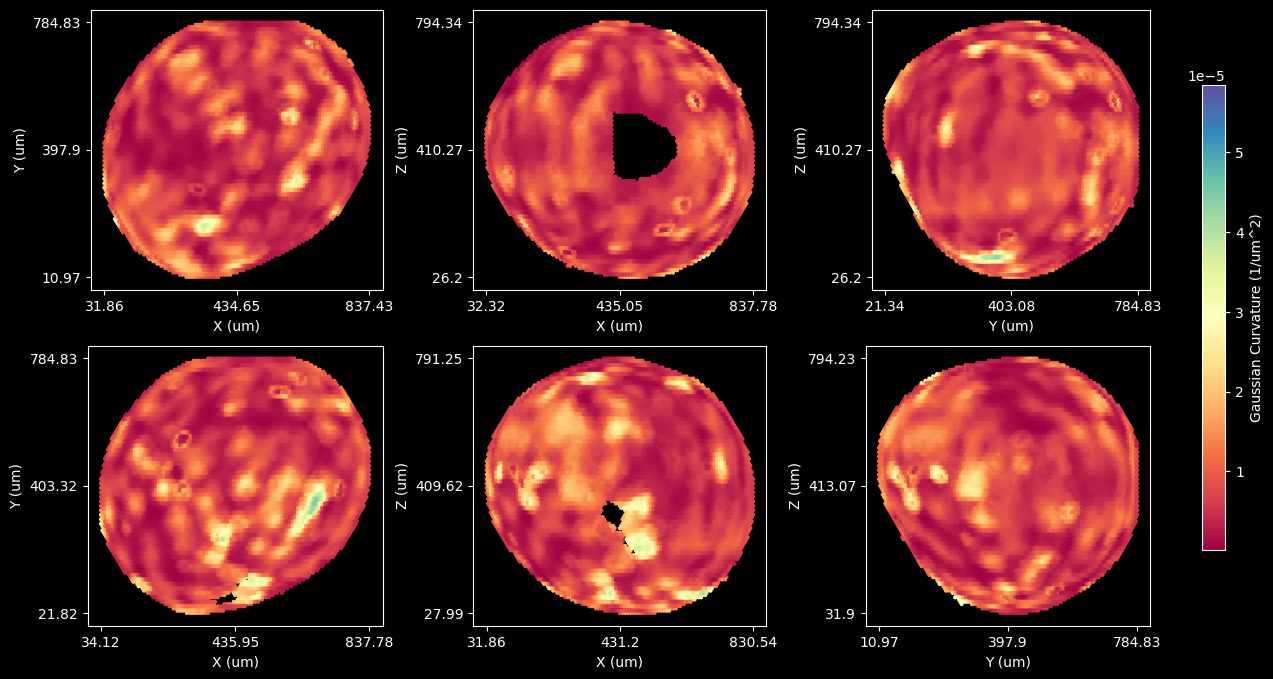

Plotting max projection of coloured points...


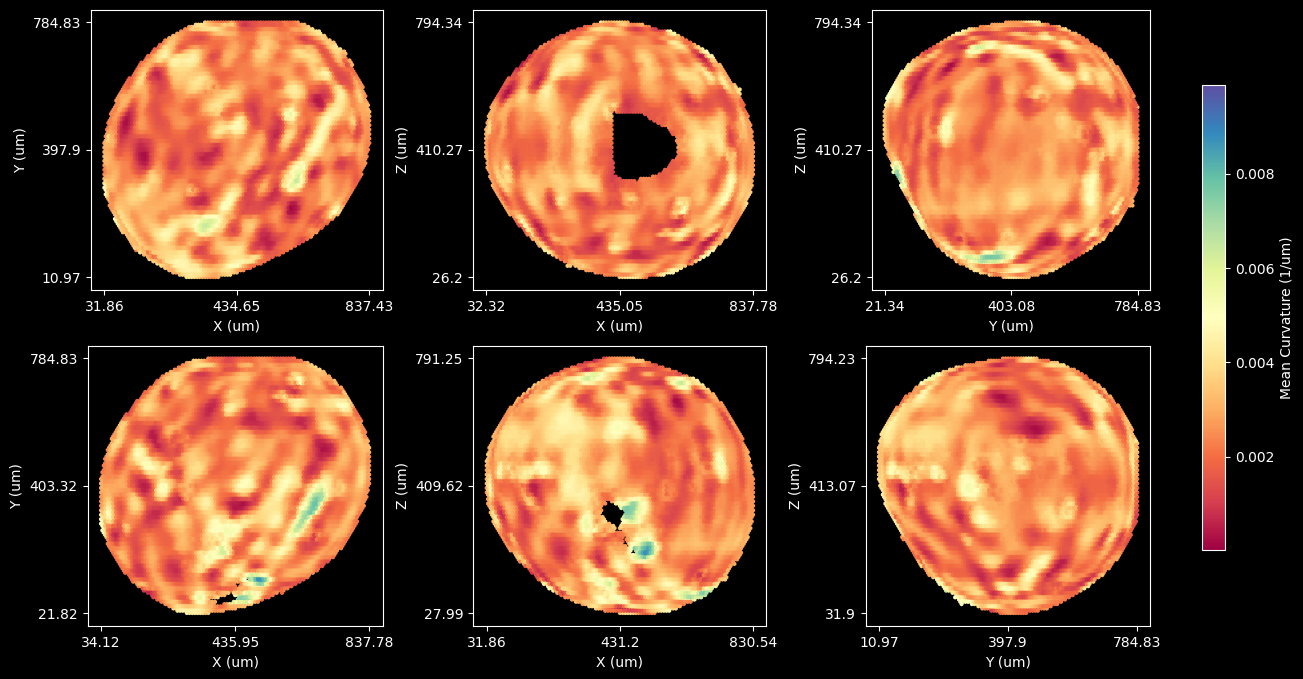

In [158]:
# ==== Calculate Gauss & Mean Curvature ====
curvature_results = analysis.curvature_by_srf_fit(mesh_2, num_sample=curvature_num_samples, k=curvature_k,
                                                  debug=True, filter_boundary=curvature_filter_boundary,
                                                  boundary_excl_factor=curvature_filter_boundary_factor,
                                                  gauss_crop_range=gauss_crop_range, mean_crop_range=mean_crop_range)

C_gauss, C_mean, C_gauss_idxs, C_mean_idxs = curvature_results
full_C_gauss_2 = analysis.interpolate_on_mesh(mesh_2, C_gauss_idxs, C_gauss, k=10)
full_C_mean_2 = analysis.interpolate_on_mesh(mesh_2, C_mean_idxs, C_mean, k=10)
# ==== Save Gauss & Mean Curvature ====
datahandler.save_array(full_C_gauss_2, "gauss_curv_2", header=f"gauss (1/{img_unit}^2)", folderpath=resdata_dir)
datahandler.save_array(full_C_mean_2, "mean_curv_2", header=f"mean (1/{img_unit})", folderpath=resdata_dir)

# ==== Plot Gauss & Mean Curvature ====
visuals.plot_hist(full_C_gauss_2, title=f"Gauss AVG = {full_C_gauss_2.mean():.2e} (1/{img_unit}^2)",
                  savefig=os.path.join(resfig_dir, "gauss_hist.png"))
visuals.plot_hist(full_C_mean_2, title=f"Mean AVG = {full_C_mean_2.mean():.2e} (1/{img_unit})",
                  savefig=os.path.join(resfig_dir, "mean_hist.png"))
visuals.plot_maxproj_pts(verts=mesh_2.vertices, unit=img_unit, colors=full_C_gauss_2, cmap="Spectral",
                         hexsize=100, cmap_label=f"Gaussian Curvature (1/{img_unit}^2)",
                         savefig=os.path.join(resfig_dir, "gauss_curv.png"))
visuals.plot_maxproj_pts(verts=mesh_2.vertices, unit=img_unit, colors=full_C_mean_2, cmap="Spectral",
                         hexsize=100, cmap_label=f"Mean Curvature (1/{img_unit})",
                         savefig=os.path.join(resfig_dir, "mean_curv.png"))

In [138]:
# ==== 3D Render Result ====
visuals.view_colored_mesh_multiple([mesh_2, mesh_2],
                                   [visuals.color_scalar(full_C_gauss_2, normalise=True, cmap="Spectral"),
                                    visuals.color_scalar(full_C_mean_2, normalise=True, cmap="Spectral")],
                                   name_list=["Gauss", "Mean"])

>> Rendering colored mesh...


### |2.1| Curvature Mesh Comparitve View

In [159]:
# ==== 3D Render Result ====
cmap_lims_render_gauss = [np.min([full_C_mean_1.min(), full_C_mean_2.min()]),
                          np.max([full_C_mean_1.max(), full_C_mean_2.max()])]
cmap_lims_render_mean = [np.min([full_C_gauss_1.min(), full_C_gauss_2.min()]),
                         np.max([full_C_gauss_1.max(), full_C_gauss_2.max()])]
visuals.view_colored_mesh_multiple([mesh_1, mesh_2, mesh_1, mesh_2],
                                   [visuals.color_scalar(full_C_mean_1, cmap="Spectral",
                                                         manual_vminmax=cmap_lims_render_gauss),
                                    visuals.color_scalar(full_C_mean_2, cmap="Spectral",
                                                         manual_vminmax=cmap_lims_render_gauss),
                                    visuals.color_scalar(full_C_gauss_1, cmap="jet",
                                                         manual_vminmax=cmap_lims_render_mean),
                                    visuals.color_scalar(full_C_gauss_2, cmap="jet",
                                                         manual_vminmax=cmap_lims_render_mean)],
                                   name_list=["Mean Mesh 1", "Mean Mesh 2", "Gauss Mesh 1", "Gauss Mesh 2"])

>> Rendering colored mesh...


# Projection onto Mesh

## |1| Find Min & Max Distance

In [ ]:
# ==== Define Projection Range ====
dist_min = 0
dist_max = 10
dist_num = 20

# ==== Specify Custom Minimum ====
dist_min_custom = None
# dist_min_custom = np.linspace(0, 5, sampl_mesh.vertices.shape[0])
# ==== Project onto Mesh ====
proj_broad = analysis.proj2mesh(img=img_raw, mesh=sampl_mesh, unit=img_unit, min_dist_per_vert=dist_min_custom,
                                scale=img_scale, min_dist=dist_min, max_dist=dist_max, num_dist=dist_num, mode="max",
                                show_proj=True, savefig=os.path.join(resfig_dir, "distgraph_broad-scan.png"),
                                normalise=False)

# ==== Plot Projected Result ====
# visuals.plot_maxproj_pts(verts=sampl_mesh.vertices, colors=proj_broad, cmap="Greens", hexsize=200,
#                          savefig=os.path.join(resfig_dir, "maxproj_broad-scan.png"), unit=img_unit, figsize=(18, 8))

In [ ]:
# ==== Plot Histogram of Projected Values ====
visuals.plot_hist(proj_broad)

In [ ]:
# ==== 3D Render Projected Result ====
visuals.view_colored_mesh(mesh=sampl_mesh,
                          vert_colors=visuals.color_scalar(proj_broad / proj_broad.max(),
                                                           cmap="Greens"),
                          mesh_blending="opaque")  #, img=img_raw, scale=img_scale)

In [ ]:
# ==== Plot Mercator Projection ====
mercator_x, mercator_y = analysis.spherical_project(
    pts=sampl_mesh.vertices)  #, ref_point=[sphere_x0, sphere_y0, sphere_z0],rotate=[90, 0, 90])
visuals.plot_mercator_project(mercator_x=mercator_x, mercator_y=mercator_y, aspect="equal",
                              intensities=proj_broad, figsize=(14, 8), ptview=False, hexgridsize=200,
                              savefig=os.path.join(resfig_dir, "distgraph_broad-scan_mercator.png"))

In [ ]:
# min_proj_dist = 2.0
# max_proj_dist = 15.0
# slice_proj = float(np.max(img_scale))
# num_proj_samples = int(np.max(img_scale) / np.min(img_scale))
# proj_mode = "max"
# min_all = np.arange(min_proj_dist, max_proj_dist, slice_proj)
# max_all = min_all + slice_proj
# mask = max_all <= max_proj_dist
# min_all, max_all = min_all[mask], max_all[mask]
# proj_tasks = np.column_stack((min_all, max_all, np.full_like(min_all, num_proj_samples)))
#
# all_projections = np.empty((len(proj_tasks), len(sampl_mesh.vertices)))
# for i, proj_task in enumerate(proj_tasks):
#     dist_min, dist_max, dist_num = proj_task
#     all_projections[i] = analysis.proj2mesh(img=img_raw, mesh=sampl_mesh, unit=img_unit, min_dist_per_vert=None,
#                                             scale=img_scale, min_dist=dist_min, max_dist=dist_max, num_dist=dist_num,
#                                             mode=proj_mode, show_proj=False, savefig="", normalise=False)
# print("=======")
# print(f"Projected {len(all_projections)} layers !!")
#
#
# proj_xcords, proj_ycords = analysis.mercator_project(pts=sampl_mesh.vertices)
# radial_stack = analysis.create_zstack(values=all_projections, phi_coords=proj_xcords, ycords=proj_ycords, grid_n=img_dim[1])
# visuals.plot_matrix(radial_stack[0], figsize=(14, 8), origin="upper")
# datahandler.save_tiff(radial_stack, filepath=os.path.join(resfig_dir, "radial-stack.tiff"))

### |1.1| EMBL Spherical Projection

In [ ]:
sphere_x0, sphere_y0, sphere_z0, sphere_radius = datahandler.load_array("sphere_fit", folderpath=resdata_dir)[0, :]
print(f"sphere_x0 = {sphere_x0} {img_unit}")
print(f"sphere_y0 = {sphere_y0} {img_unit}")
print(f"sphere_z0 = {sphere_z0} {img_unit}")
print(f"sphere_radius = {sphere_radius} {img_unit}")

In [ ]:
min_proj_dist = 10.0
max_proj_dist = 200.0
slice_proj = 5.0
num_proj_samples = int(np.max(img_scale) / np.min(img_scale))
proj_mode = "mean"
min_all = np.arange(min_proj_dist, max_proj_dist, slice_proj)
max_all = min_all + slice_proj
mask = max_all <= max_proj_dist
min_all, max_all = min_all[mask], max_all[mask]
proj_tasks = np.stack([
    min_all,
    max_all,
    np.full(min_all.shape, num_proj_samples)
], axis=1)

proj_radii = sphere_radius - (min_all + 0.5 * slice_proj)
print(f">> Projecting at radii {proj_radii} {img_unit} ...")
# Flip direction of projection for going "inwards"
proj_tasks[:, :2] *= -1

all_projections = np.empty((len(proj_tasks), len(sampl_mesh.vertices)))
for i, proj_task in enumerate(proj_tasks):
    dist_min, dist_max, dist_num = proj_task
    all_projections[i] = analysis.proj2mesh(img=img_raw, mesh=sampl_mesh, unit=img_unit, min_dist_per_vert=None,
                                            scale=img_scale, min_dist=dist_min, max_dist=dist_max, num_dist=dist_num,
                                            mode=proj_mode, show_proj=False, savefig="", normalise=False)
print("=======")
print(f"Projected {len(all_projections)} layers !!")

In [ ]:
proj_xcords, proj_ycords = analysis.spherical_project(pts=sampl_mesh.vertices,
                                                      ref_point=[sphere_x0, sphere_y0, sphere_z0])
radial_projection = analysis.create_radial_stack(values=all_projections,
                                                 phi_coords=proj_xcords,
                                                 theta_cords=proj_ycords,
                                                 grid_n=np.mean(img_dim[1:]), projection_radii=proj_radii)
radial_stack, stack_cords = radial_projection
mid_radial_stack_i = radial_stack.shape[0] // 2

visuals.plot_matrix(radial_stack[mid_radial_stack_i], figsize=(14, 8), origin="upper",
                    title=f"R = {proj_radii[mid_radial_stack_i]:,.2f} {img_unit}",
                    savefig=os.path.join(resfig_dir, f"radial-stack_{mid_radial_stack_i}.png"),
                    unit="px", colorbar=True, cmap="inferno")

np.savez_compressed(os.path.join(resdata_dir, "radial_projection.npz"), radial_stack=radial_stack,
                    stack_cords=stack_cords)

In [ ]:
radial_stack = np.load(os.path.join(resdata_dir, "radial_projection.npz"))["radial_stack"]
stack_cords = np.load(os.path.join(resdata_dir, "radial_projection.npz"))["stack_cords"]

datahandler.save_tiff(radial_stack, filepath=os.path.join(resfig_dir, "radial-stack.tiff"))

In [ ]:
visuals.view_colored_mesh_multiple([sampl_mesh, sampl_mesh], vert_colors_list=[
    visuals.color_scalar(analysis.normalise_range(all_projections[0]), cmap="Greens_r"),
    visuals.color_scalar(analysis.normalise_range(all_projections[2]), cmap="Greens_r")])

In [ ]:
# stack_coords_phi = stack_cords[0, ..., 0]
# visuals.plot_matrix(stack_coords_phi, origin="upper", colorbar=True, cmap="coolwarm")
# stack_coords_theta = stack_cords[0, ..., 1]
# visuals.plot_matrix(stack_coords_theta, origin="upper", colorbar=True, cmap="coolwarm")
# stack_coords_radii = stack_cords[:, 0, 0, 2]
# plt.figure()
# plt.hexbin(proj_ycords, proj_xcords, all_projections[0], gridsize=100)
# plt.gca().invert_yaxis()
# plt.gca().invert_xaxis()
# plt.show()

In [ ]:
# # ==== Experimental: Mercator Projection relative to Sphere Fit ====
# sphere_params_load = datahandler.load_array("sphere_fit", folderpath=resdata_dir)
# sphere_x0, sphere_y0, sphere_z0, sphere_radius = sphere_params_load[0, :]
# mercator_x, mercator_y = analysis.mercator_project(
#     pts=sampl_mesh.vertices, ref_point=[sphere_x0, sphere_y0, sphere_z0])
# visuals.plot_mercator_project(mercator_x=mercator_x, mercator_y=mercator_y, cmap="Greens_r",invert_y_axis=True,
#                               intensities=proj_broad, figsize=(14, 8), ptview=True, aspect="equal",
#                               savefig=os.path.join(resfig_dir, "distgraph_broad-scan_mercator.png"), ptsize=0.1)
# # ==== Experimental: Different Angle Mercator Projection relative to Sphere Fit ====
# # rotation_angles = [[0, 0, 0],
# #                    [np.pi / 4, 0, 0],
# #                    [np.pi / 2, 0, 0],
# #                    [np.pi / 2, 0, np.pi / 2]]
# # for rot_angles in rotation_angles:
# #     print(f"Rotation angles: {np.degrees(rot_angles)}")
# #     mercator_x, mercator_y = analysis.mercator_project(
# #         pts=sampl_mesh.vertices, rotate=rot_angles, ref_point=[sphere_x0, sphere_y0, sphere_z0])
# #     visuals.plot_mercator_project(mercator_x=mercator_x, mercator_y=mercator_y, intensities=proj_broad,
# #                                   aspect="equal", ptview=True, figsize=(14, 8))

## |2| Check Multi-Layering

In [ ]:
# ==== Define Projection Range and Intermediate Value ====
dist_middle = dist_min + (dist_max - dist_min) / 2
dist_num = 50
print(f"Chosen Middle Distance {dist_middle} {img_unit}")
# ==== Specify Custom Minimum ====
dist_min_custom = None
# dist_min_custom = np.linspace(0, 5, sampl_mesh.vertices.shape[0])

# ==== Project onto Mesh ====
proj_full = analysis.proj2mesh(img=img_raw, mesh=sampl_mesh, min_dist_per_vert=dist_min_custom,
                               scale=img_scale, min_dist=dist_min, max_dist=dist_max, num_dist=dist_num, mode="max",
                               show_proj=False, return_full=True, unit=img_unit, normalise=False)
# ==== Plot Projected Result ====
distances, dist_points, radial_intensities = proj_full
distcolor, distcmap = visuals.colour_dist(distances=distances, middle_val=dist_max - dist_middle,
                                          radial_points=dist_points, mesh=sampl_mesh,
                                          radial_intensities=radial_intensities)
visuals.plot_maxproj_pts(verts=sampl_mesh.vertices, colors=distcolor, unit=img_unit, cmap=distcmap, hexsize=300,
                         savefig=os.path.join(resfig_dir, "maxproj_multi-layer.png"))

In [ ]:
# ==== Plot Mercator Projection ====
mercator_x, mercator_y = analysis.spherical_project(
    pts=sampl_mesh.vertices)  #,ref_point=[sphere_x0, sphere_y0, sphere_z0])
visuals.plot_mercator_project(mercator_x=mercator_x, mercator_y=mercator_y, intensities=distcolor, ptview=True,
                              figsize=(14, 8), cmap=distcmap,
                              savefig=os.path.join(resfig_dir, "multi-layer_mercator.png"))

In [ ]:
# ==== 3D Render Projected Result ====
# visuals.view_verts(verts=verts_distcolor, colors=distcolor, blending="opaque", opacity=0.6, point_size=1)
visuals.view_colored_mesh(mesh=sampl_mesh, color_override=distcolor)  #, img=img_raw, scale=img_scale)

In [ ]:
# # ==== Plot Mercator Projections ====
# rotation_angles = [[0, 0, 0],
#                    [np.pi / 4, 0, 0],
#                    [np.pi / 2, 0, 0],
#                    [np.pi / 2, 0, np.pi / 2]]
# for rot_angles in rotation_angles:
#     print(f"Rotation angles: {np.degrees(rot_angles)}")
#     mercator_x, mercator_y = analysis.spherical_project(
#         pts=sampl_mesh.vertices, rotate=rot_angles)
#     visuals.plot_mercator_project(mercator_x=mercator_x, mercator_y=mercator_y, intensities=distcolor, ptview=True,
#                                   figsize=(5, 5), cmap=distcmap)

## |3| Isolate single layer

In [ ]:
# ==== Choose Projection Mode: full / inner / outer ====
layer_label = "full"

try:
    dist_middle
except:
    dist_middle = dist_min + (dist_max - dist_min) / 2

# ==== Specify Custom Minimum ====
dist_min_custom = None
# dist_min_custom = np.linspace(0, 5, sampl_mesh.vertices.shape[0])

resdata_dir_layer = os.path.join(resdata_dir, layer_label)
resfig_dir_layer = os.path.join(resfig_dir, layer_label)
if not os.path.exists(resdata_dir_layer):
    os.makedirs(resdata_dir_layer)
if not os.path.exists(resfig_dir_layer):
    os.makedirs(resfig_dir_layer)

# ==== Save Sampling Vertices and Normals ====
datahandler.save_array(sampl_mesh.vertices, "verts", header="x,y,z", folderpath=resdata_dir_layer)
datahandler.save_array(sampl_mesh.vertex_normals, "normals", header="nx,ny,nz", folderpath=resdata_dir_layer)

if layer_label == "inner":
    min_radial_dist = dist_min
    max_radial_dist = dist_middle
elif layer_label == "outer":
    min_radial_dist = dist_middle
    max_radial_dist = dist_max
elif layer_label == "full":
    min_radial_dist = dist_min
    max_radial_dist = dist_max
else:
    min_radial_dist = dist_min
    max_radial_dist = dist_max

num_radial_dist = 30

# ==== Project onto Mesh ====
proj_layer = analysis.proj2mesh(img=img_raw, mesh=sampl_mesh, min_dist_per_vert=dist_min_custom,
                                scale=img_scale, min_dist=min_radial_dist, max_dist=max_radial_dist,
                                num_dist=num_radial_dist, mode="max", show_proj=True,
                                savefig=os.path.join(resfig_dir_layer, f"distgraph.png"), unit=img_unit,
                                normalise=False)

# ==== Save Projection ====
datahandler.save_array(proj_layer, "intensities", header="I", folderpath=resdata_dir_layer)

# ==== Plot Projected Result ====
mercator_x, mercator_y = analysis.spherical_project(pts=sampl_mesh.vertices)
visuals.plot_mercator_project(mercator_x=mercator_x, mercator_y=mercator_y, intensities=proj_layer, hexgridsize=400,
                              savefig=os.path.join(resfig_dir_layer, "mercator.png"))

In [ ]:
# ==== 3D Render Projected Result ====
# visuals.view_colored_verts(verts=sampl_mesh.vertices, colors=visuals.color_scalar(analysis.normalise_range(proj_layer), cmap="Greens_r"),
#                            scale=img_scale,img=None, ptsize=2)
# visuals.view_colored_mesh(mesh=sampl_mesh, vert_colors=visuals.color_scalar(analysis.normalise_range(proj_layer),
#                                                                             cmap="Greens_r"))  #, img=img_raw, scale=img_scale)

# -- Load Layer --

>> Loaded .../intensities.csv | cols ['I'] | shape (596867,)


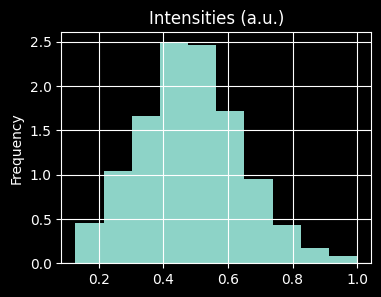

>> Applying Spherical Projection...
>> Plotting the mercator projection...


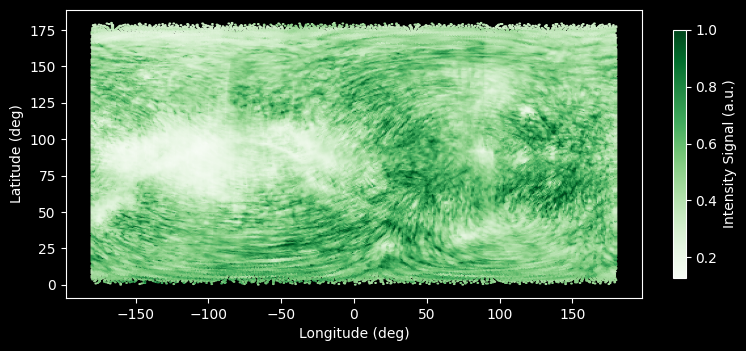

In [20]:
# ==== Load Projected Result: full / inner / outer ====
layer_label = "full"
resdata_dir_layer = os.path.join(resdata_dir, layer_label)
resfig_dir_layer = os.path.join(resfig_dir, layer_label)
proj_layer = datahandler.load_array("intensities", folderpath=resdata_dir_layer)
# proj_layer = analysis.normalise_range(proj_layer)
proj_layer /= proj_layer.max()

# ==== Plot Projected Result ====
visuals.plot_hist(proj_layer, title="Intensities (a.u.)")
mercator_x, mercator_y = analysis.spherical_project(
    pts=sampl_mesh.vertices)  #, ref_point=[sphere_x0, sphere_y0, sphere_z0])
visuals.plot_mercator_project(mercator_x=mercator_x, mercator_y=mercator_y, intensities=proj_layer, hexgridsize=400,
                              aspect="equal")

In [ ]:
# ==== 3D Render Projected Result ====
# visuals.view_colored_verts(verts=sampl_mesh.vertices,
#                            colors=visuals.color_scalar(analysis.normalise_range(proj_layer), cmap="inferno"),
#                            scale=img_scale, img=None, ptsize=0.7)
visuals.view_colored_mesh(mesh=sampl_mesh, vert_colors=visuals.color_scalar(analysis.normalise_range(proj_layer),
                                                                            cmap="Greens"), img=img_raw,
                          scale=img_scale)

# -- Nematic Extraction & Analysis --

## |1| 2D Slice

### |1.1| Directors + S order

In [ ]:
# ==== Choose Slices for Analysis ====
sel_slices = np.arange(img_raw.shape[0])
sel_slices = [img_dim[0] // 2]
mask_thresh_val = 0.8 * np.min(analysis.yen_thresh(img_raw[sel_slices]))
img_selected = img_raw[img_dim[0] // 2].copy()

# ==== Saving Parameters  ====
figsize = (4, 4)
resfig_dir_2dsliced = os.path.join(resfig_dir, "2d-sliced_analysis")
resdata_dir_2dsliced = os.path.join(resdata_dir, "2d-sliced_analysis")
datahandler.create_dir(resfig_dir_2dsliced)
datahandler.create_dir(resdata_dir_2dsliced)

# ==== Analysis Parameters ====
boxsize = 2 * 32
k = 5 ** 2
results_2d_slice = []

# ==== Enable Plotting ====
plot_figs = False

for i in sel_slices:
    print(f">> Analysing Z slice {i}")
    img_selected = img_raw[i].copy()
    # ==== 2D Orientation Analysis ====
    orient2d_results = analysis.orient2d(img=img_selected, boxsize=boxsize, thresh_val=mask_thresh_val, num_neigh_nem=k,
                                         debug=False)
    theta_all_deg, theta_masked_rad, S_2d, n_avg_2d, X, Y, directors_2d = orient2d_results

    directors_2d[:, 0] *= img_scale[1]
    directors_2d[:, 1] *= img_scale[2]
    directors_2d[:, :2] = directors_2d[:, [1, 0]]
    directors_2d_avg_local = np.column_stack((directors_2d[:, :2], n_avg_2d))
    results_2d_slice.append([i, np.nanmean(theta_all_deg), np.nanmean(S_2d)])
    interval = 500
    directors_2d, directors_2d_avg_local, S_2d = directors_2d[::interval], directors_2d_avg_local[::interval], S_2d[
                                                                                                               ::interval]
    print(f"Found {len(directors_2d)} directors !")

    # ==== Save Directors and Order ====
    datahandler.save_array(directors_2d, f"directors_2d_z-{i}", header="x,y,vx,vy", folderpath=resdata_dir_2dsliced)
    datahandler.save_array(S_2d, f"S-order_2d_k-{k}_z-{i}", header="S", folderpath=resdata_dir_2dsliced)
    datahandler.save_array(directors_2d_avg_local, f"directors-avg_2d_k-{k}_z-{i}",
                           header="x,y,vx,vy",
                           folderpath=resdata_dir_2dsliced)
    if plot_figs:
        # ==== Plot Results ====
        savefig_i = os.path.join(resfig_dir_2dsliced, f"z-{i}.png")
        savefig_theta = os.path.join(resfig_dir_2dsliced, f"z-{i}_theta.png")
        savefig_i_dirs = os.path.join(resfig_dir_2dsliced, f"z-{i}_dirs")
        savefig_dirs_s = os.path.join(resfig_dir_2dsliced, f"z-{i}_dirs_s")
        savefig_theta_hist_polar = os.path.join(resfig_dir_2dsliced, f"z_{i}_theta_hist.png")

        visuals.plot_matrix(img_selected, scale=img_scale, cmap='Greys_r', colorbar=True,
                            title='Intensity Profile', unit=img_unit,
                            figsize=figsize, savefig=savefig_i)
        visuals.plot_matrix(theta_all_deg, scale=img_scale, cmap='twilight', colorbar=True,
                            unit=img_unit,
                            title=f'Theta Angles for block {boxsize}x{boxsize}', figsize=figsize,
                            savefig=savefig_theta,
                            cmap_limits=[-90, 90])
        visuals.plot_polar_hist(angles_deg=theta_all_deg, savefig=savefig_theta_hist_polar, figsize=figsize)
        visuals.plot_hist(array=S_2d, title="order parameter $S$", figsize=figsize, savefig=savefig_dirs_s)

        # visuals.plot_matrix_vectors(Y, X, theta_masked_rad.T, img_selected, title="Intensity Profile + Directors",
        #                             figsize=(figsize[0] * 2, figsize[1]),
        #                             veclength=10, savefig=savefig_i_dirs, vec_colors=S_2d,
        #                             scale=img_scale,
        #                             cbar_matrix_label="Intensity Signal (a.u.)",
        #                             cbar_vector_label="order parameter $S$")

results_2d_slice = np.array(results_2d_slice)

### -- Load Segmentation Results --

In [ ]:
local_nneigh = 5
crop_max_ar = 5  # Max for colorbar !
local_S_weighted_max = 3.0  # Max for colorbar !

z_range_2d_analysis = np.arange(img_dim[0])
# z_range_2d_analysis = [img_dim[0] // 2]

hide_all_figs = True
dpi_all_figs = 100
figsize = (22, 10)

In [ ]:
directors_2d_all = []
aspect_ratio_all = []
valid_2dseg_idxs = []
masks = mask_outlines = None
only_load_ellip = True
for z_sel in z_range_2d_analysis:
    print(f">> Z-slice selected: {z_sel}")

    # ==== Load Slice Segmentation Results ====
    seg_ellips_results = datahandler.load_array(name=f"2d-sliced_analysis/{z_sel + 1:04d}", folderpath=resdata_dir,
                                                return_df=True)

    # ==== Process (or skip empty) Slice Segmentations ====
    if seg_ellips_results is not None:
        seg_ellips_results["aspect_ratio"] = seg_ellips_results["Ellipse.Radius1"] / seg_ellips_results[
            "Ellipse.Radius2"]
        seg_ellips_results["Ellipse.Orientation"] *= -1
        valid_2dseg_idxs.append(z_sel)

        # ==== [!!] ONLY DEBUG [!] ====
        # seg_ellips_results["Ellipse.Orientation"] = np.ones(len(seg_ellips_results["Ellipse.Orientation"])) * 0  # !!!!!!
        # seg_ellips_results["Ellipse.Orientation"] = np.random.uniform(-180, 180, size=len(seg_ellips_results["Ellipse.Orientation"]))
        # seg_ellips_results["aspect_ratio"] = np.ones(len(seg_ellips_results["aspect_ratio"])) * 2
        seg_ellips_results = seg_ellips_results[seg_ellips_results["aspect_ratio"] < crop_max_ar]
        # ==== [!!] ONLY DEBUG [!] ====
        if not only_load_ellip:
            # ==== Load Segmentation Masks ====
            masks = datahandler.load_png(
                f"/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/2pGPI_EXP1_25052025/48h/EXP1_GPI_48h_Pos1/data/2d-sliced_analysis/EXP1_GPI_48h_Pos1-{z_sel + 1:04d}_cp_masks.png")
            if masks is not None:
                mask_outlines = analysis.contour_masks(masks)
            else:
                print(f"No masks found for {z_sel}, continuing to next z slice...")
                continue
    else:
        print(f"No segmentation found for {z_sel}, continuing to next z slice...")
        continue

    # ==== Saving Path Initialisation ====
    resfig_dir_2dsliced = os.path.join(resfig_dir, "2d-sliced_analysis")
    resdata_dir_2dsliced = os.path.join(resdata_dir, "2d-sliced_analysis")
    datahandler.create_dir(resfig_dir_2dsliced)
    datahandler.create_dir(resdata_dir_2dsliced)

    # ==== Convert Orientations to Director Field ====
    seg_directors_2d = np.column_stack((seg_ellips_results["Ellipse.Center.X"],
                                        seg_ellips_results["Ellipse.Center.Y"],
                                        np.cos(np.radians(seg_ellips_results["Ellipse.Orientation"])),
                                        np.sin(np.radians(seg_ellips_results["Ellipse.Orientation"]))))
    print("Max aspect ratio =", np.max(seg_ellips_results["aspect_ratio"]))
    seg_directors_2d[:, :2] *= img_scale[1:]
    directors_2d = seg_directors_2d.copy()
    directors_2d_all.append(directors_2d)
    aspect_ratio_all.append(np.array(seg_ellips_results["aspect_ratio"]))

    if not only_load_ellip:
        # ==== Local (Weighted) Nematic Order ====
        seg_ellips_results["shape_scalar"] = seg_ellips_results["aspect_ratio"] - 1
        if len(directors_2d) <= local_nneigh:
            print(f"Only {len(directors_2d)} directors, using k=2 ...")
            local_nneigh = 2
        local_idxs = analysis.coord_search_neighbours(directors_2d[:, :2], k=local_nneigh)
        S_2d_seg_local, n_2d_seg_local = analysis.avg_2d_nem_tens(directors_2d, weights=None,
                                                                  neigh_idxs=local_idxs)
        S_2d_seg_local_weighted, n_2d_seg_local = analysis.avg_2d_nem_tens(directors_2d, local_idxs,
                                                                           weights=np.array(
                                                                               seg_ellips_results["shape_scalar"]))

        # ==== Plot Results ====
        z_sel_label = f"| Z = {z_sel} / {img_dim[0] - 1}"
        visuals.plot_polar_hist(seg_ellips_results["Ellipse.Orientation"],
                                savefig=os.path.join(resfig_dir_2dsliced, f"z-{z_sel}_seg_thetas_polar-hist.png"),
                                hidefig=hide_all_figs, dpi=dpi_all_figs, title=f"Orientation Angles {z_sel_label}")
        visuals.plot_hist(seg_ellips_results["aspect_ratio"], title=f"Aspect Ratio {z_sel_label}",
                          savefig=os.path.join(resfig_dir_2dsliced, f"z-{z_sel}_seg_ar_hist.png"),
                          hidefig=hide_all_figs,
                          xlim=[0, crop_max_ar], dpi=dpi_all_figs)
        visuals.plot_matrix_vectors(x=seg_ellips_results["Ellipse.Center.X"], y=seg_ellips_results["Ellipse.Center.Y"],
                                    angle_field=np.radians(seg_ellips_results["Ellipse.Orientation"]),
                                    matrix=img_raw[z_sel], veclength=15 * np.array(seg_ellips_results["aspect_ratio"]),
                                    scale=img_scale, unit=img_unit, figsize=figsize,
                                    vec_colors=seg_ellips_results["aspect_ratio"],
                                    cbar_matrix_label="Intensity Signal (a.u.)",
                                    cbar_vector_label="Aspect Ratio",
                                    title=f"Segmented Ellipse Long Axes {z_sel_label}",
                                    savefig=os.path.join(resfig_dir_2dsliced, f"z-{z_sel}_seg_raw_ar.png"),
                                    hidefig=hide_all_figs, vec_cmap_limits=[0, crop_max_ar], dpi=dpi_all_figs)
        visuals.plot_img_2d_masks(matrix=img_raw[z_sel], unit=img_unit, scale=img_scale,
                                  segmentation_mask=(masks, mask_outlines),
                                  figsize=figsize, cmap="tab20", alpha=0.8, title=f"Segmentation Masks {z_sel_label}",
                                  savefig=os.path.join(resfig_dir_2dsliced, f"z-{z_sel}_seg_raw_masks.png"),
                                  hidefig=hide_all_figs, dpi=dpi_all_figs)
        visuals.plot_matrix_vectors(x=seg_ellips_results["Ellipse.Center.X"], y=seg_ellips_results["Ellipse.Center.Y"],
                                    angle_field=np.radians(seg_ellips_results["Ellipse.Orientation"]),
                                    matrix=img_raw[z_sel], veclength=15 * np.array(seg_ellips_results["aspect_ratio"]),
                                    scale=img_scale, unit=img_unit, figsize=figsize, vec_colors=S_2d_seg_local,
                                    vec_cmap_limits=[0, 1], cbar_matrix_label="Intensity Signal (a.u.)",
                                    cbar_vector_label="Local Nematic Order $S$",
                                    title=f"Local Nematic Order {z_sel_label}",
                                    savefig=os.path.join(resfig_dir_2dsliced, f"z-{z_sel}_seg_raw_local_S.png"),
                                    hidefig=hide_all_figs, dpi=dpi_all_figs)
        visuals.plot_slice_heatmap(coords=directors_2d[:, :2], values=S_2d_seg_local,
                                   cmap_label="Local Nematic Order", title=f"Local Nematic Order {z_sel_label}",
                                   img_dim=img_dim, img_scale=img_scale, manual_vminvmax=[0, 1],
                                   savefig=os.path.join(resfig_dir_2dsliced, f"z-{z_sel}_seg_local_S_heatmap.png"),
                                   hidefig=hide_all_figs, dpi=dpi_all_figs)
        visuals.plot_hist(S_2d_seg_local, title=f"Local Nematic Order $S$ {z_sel_label}",
                          savefig=os.path.join(resfig_dir_2dsliced, f"z-{z_sel}_seg_local_S_hist.png"),
                          hidefig=hide_all_figs, xlim=[0, 1], dpi=dpi_all_figs)
        visuals.plot_matrix_vectors(x=seg_ellips_results["Ellipse.Center.X"], y=seg_ellips_results["Ellipse.Center.Y"],
                                    angle_field=np.radians(seg_ellips_results["Ellipse.Orientation"]),
                                    matrix=img_raw[z_sel], veclength=15 * np.array(seg_ellips_results["aspect_ratio"]),
                                    scale=img_scale, unit=img_unit, figsize=figsize, vec_colors=S_2d_seg_local_weighted,
                                    cbar_matrix_label="Intensity Signal (a.u.)",
                                    vec_cmap_limits=[0, local_S_weighted_max],
                                    cbar_vector_label="Local Weighted Nematic Order $S$",
                                    title=f"Local Weighted Nematic Order {z_sel_label}",
                                    savefig=os.path.join(resfig_dir_2dsliced,
                                                         f"z-{z_sel}_seg_raw_local_S_weighted.png"),
                                    hidefig=hide_all_figs, dpi=dpi_all_figs)
        visuals.plot_slice_heatmap(coords=directors_2d[:, :2], values=S_2d_seg_local_weighted,
                                   cmap_label="Local Weighted Nematic Order",
                                   title=f"Local Weighted Nematic Order {z_sel_label}",
                                   img_dim=img_dim, img_scale=img_scale, manual_vminvmax=[0, local_S_weighted_max],
                                   savefig=os.path.join(resfig_dir_2dsliced,
                                                        f"z-{z_sel}_seg_local_S_weighted_heatmap.png"),
                                   hidefig=hide_all_figs, dpi=dpi_all_figs)
        visuals.plot_hist(S_2d_seg_local_weighted, title=f"Local Weighted Nematic Order $S$ {z_sel_label}",
                          savefig=os.path.join(resfig_dir_2dsliced, f"z-{z_sel}_seg_local_S_weighted_hist.png"),
                          hidefig=hide_all_figs, xlim=[0, local_S_weighted_max], dpi=dpi_all_figs)
valid_2dseg_idxs = np.array(valid_2dseg_idxs, dtype=int)

In [ ]:
# ==== Save Result Figures as .gif ====
datahandler.save_gif_multiple(folderpath=os.path.join(resfig_dir, "2d-sliced_analysis"))

### (experimental) 3D Reconstruction

In [ ]:
valid_2dseg_idxs = []
dirs_test = []
ar_test = []
masks_all = []
for z_sel in z_range_2d_analysis:
    print(f">> Z-slice selected: {z_sel}")

    # ==== Load Slice Segmentation Results ====
    seg_ellips_results = datahandler.load_array(name=f"2d-sliced_analysis/{z_sel + 1:04d}", folderpath=resdata_dir,
                                                return_df=True)

    # ==== Process (or skip empty) Slice Segmentations ====
    if seg_ellips_results is not None:
        seg_ellips_results["aspect_ratio"] = seg_ellips_results["Ellipse.Radius1"] / seg_ellips_results[
            "Ellipse.Radius2"]
        seg_ellips_results["Ellipse.Orientation"] *= -1
        # ==== [!!] ONLY DEBUG [!] ====
        seg_ellips_results = seg_ellips_results[seg_ellips_results["aspect_ratio"] < crop_max_ar]
        # ==== [!!] ONLY DEBUG [!] ====

        # ==== Load Segmentation Masks ====
        masks = datahandler.load_png(
            f"/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/2pGPI_EXP1_25052025/48h/EXP1_GPI_48h_Pos1/data/2d-sliced_analysis/EXP1_GPI_48h_Pos1-{z_sel + 1:04d}_cp_masks.png")
        if masks is not None:
            masks_all.append(masks)
            valid_2dseg_idxs.append(z_sel)
        else:
            print(f"No masks found for {z_sel}, continuing to next z slice...")
            continue

    else:
        print(f"No segmentation found for {z_sel}, continuing to next z slice...")
        continue

    # ==== Saving Path Initialisation ====
    resfig_dir_2dsliced = os.path.join(resfig_dir, "2d-sliced_analysis")
    resdata_dir_2dsliced = os.path.join(resdata_dir, "2d-sliced_analysis")
    datahandler.create_dir(resfig_dir_2dsliced)
    datahandler.create_dir(resdata_dir_2dsliced)

    # ==== Convert Orientations to Director Field ====
    seg_directors_2d = np.column_stack((seg_ellips_results["Ellipse.Center.X"],
                                        seg_ellips_results["Ellipse.Center.Y"],
                                        np.cos(np.radians(seg_ellips_results["Ellipse.Orientation"])),
                                        np.sin(np.radians(seg_ellips_results["Ellipse.Orientation"]))))
    print("Max aspect ratio =", np.max(seg_ellips_results["aspect_ratio"]))
    seg_directors_2d[:, :2] *= img_scale[1:]
    directors_2d = seg_directors_2d.copy()
    ar_test.append(np.array(seg_ellips_results["aspect_ratio"]))
    dirs_test.append(directors_2d)
dirs_test = np.concatenate(dirs_test)
zpos = np.concatenate([np.ones_like(ar_test[i]) * idx * img_scale[0] for i, idx in enumerate(valid_2dseg_idxs)])
ar_test = np.concatenate(ar_test)
masks_all = np.stack(masks_all)
valid_2dseg_idxs = np.array(valid_2dseg_idxs)
full_masks = np.zeros(shape=img_dim, dtype=np.int32)
full_masks[valid_2dseg_idxs] = masks_all

In [ ]:
# ==== Render 2D Segmentations in 3D ====
directors_2dplus = np.column_stack(
    (zpos, dirs_test[:, 1], dirs_test[:, 0],
     np.zeros(len(dirs_test)), -dirs_test[:, 3] * ar_test, dirs_test[:, 2] * ar_test))
# visuals.view_3d_vector_field(vec_pos=directors_2dplus[:, :3], vec_dir=directors_2dplus[:, 3:],
#                              vec_colors=visuals.color_scalar(ar_test, manual_vminmax=[0, crop_max_ar]), length=2,
#                              img=img_raw, scale=img_scale)

# k = 7 ** 3
# idxs = analysis.coord_search_neighbours(directors_2dplus, k=k, n_process=10)
# S_2dplus, n_avg_2dplus = analysis.avg_3d_nem_tens(directors=directors_2dplus, neigh_idxs=idxs)
# visuals.view_3d_vector_field(vec_pos=directors_2dplus[:, :3], vec_dir=directors_2dplus[:, 3:],
#                              vec_colors=visuals.color_scalar(S_2dplus, manual_vminmax=[0, 1]), length=2)


In [ ]:
import numpy as np
from scipy.sparse import csr_matrix
from scipy.optimize import linear_sum_assignment
from collections import deque


def compute_overlap_fraction(curr_mask, prev_mask, curr_labels, prev_labels):
    curr_flat = curr_mask.ravel()
    prev_flat = prev_mask.ravel()
    valid = (curr_flat > 0) & (prev_flat > 0)

    curr_vals = curr_flat[valid]
    prev_vals = prev_flat[valid]

    if curr_vals.size == 0 or prev_vals.size == 0:
        return np.zeros((len(curr_labels), len(prev_labels))), np.zeros((len(curr_labels), len(prev_labels))), np.zeros(
            len(curr_labels))

    max_curr = max(curr_vals.max(), curr_labels.max())
    max_prev = max(prev_vals.max(), prev_labels.max())
    lut_curr = np.full(max_curr + 1, -1, dtype=np.int32)
    lut_prev = np.full(max_prev + 1, -1, dtype=np.int32)

    lut_curr[curr_labels] = np.arange(len(curr_labels))
    lut_prev[prev_labels] = np.arange(len(prev_labels))

    curr_indices = lut_curr[curr_vals]
    prev_indices = lut_prev[prev_vals]

    valid_idx = (curr_indices >= 0) & (prev_indices >= 0)
    curr_indices = curr_indices[valid_idx]
    prev_indices = prev_indices[valid_idx]

    data = np.ones_like(curr_indices, dtype=np.uint32)
    overlap = csr_matrix((data, (curr_indices, prev_indices)), shape=(len(curr_labels), len(prev_labels))).toarray()

    curr_areas = np.bincount(curr_indices, minlength=len(curr_labels))
    prev_areas = np.bincount(prev_indices, minlength=len(prev_labels))

    unions = curr_areas[:, None] + prev_areas[None, :] - overlap
    with np.errstate(divide='ignore', invalid='ignore'):
        rel_overlap = np.where(unions > 0, overlap / unions, 0)

    return rel_overlap, overlap, curr_areas


def stitch_masks_3d(masks_all, min_rel_overlap=0.3, memory=2):
    z_dim, H, W = masks_all.shape
    stitched = np.zeros((z_dim, H, W), dtype=np.int32)
    label_offset = 1

    history_masks = deque(maxlen=memory)
    history_labels = deque(maxlen=memory)
    history_areas = deque(maxlen=memory)

    # For fast lookups, keep a single concatenated prev_mask & labels at each iteration:
    for z in range(z_dim):
        print(f">> Z-slice {z} / {z_dim - 1} | Num Cells: {stitched.max()}")
        curr_mask = masks_all[z]
        curr_labels = np.unique(curr_mask)
        curr_labels = curr_labels[curr_labels > 0]
        if len(curr_labels) == 0:
            continue

        new_mask = np.zeros_like(curr_mask)

        if len(history_masks) == 0:
            # First frame: assign fresh labels
            mapping = {lbl: label_offset + i for i, lbl in enumerate(curr_labels)}
            label_offset += len(curr_labels)
            for lbl, new_lbl in mapping.items():
                new_mask[curr_mask == lbl] = new_lbl
        else:
            # **Build combined prev mask & labels ONCE per frame**
            # Combine history masks by assigning unique labels with offset
            # Instead of summing masks (slow & ambiguous), stack with adjusted labels:
            prev_labels_combined = []
            prev_masks_combined = np.zeros_like(curr_mask, dtype=np.int32)

            offset = 0
            for hm, hl in zip(history_masks, history_labels):
                hm_nonzero = hm > 0
                hm_relabel = np.zeros_like(hm, dtype=np.int32)
                # Relabel history masks with offset + label index:
                relabel_map = {old: new for old, new in zip(hl, range(offset + 1, offset + 1 + len(hl)))}
                for old_label, new_label in relabel_map.items():
                    hm_relabel[hm == old_label] = new_label
                prev_masks_combined[hm_nonzero] = hm_relabel[hm_nonzero]
                prev_labels_combined.extend(range(offset + 1, offset + 1 + len(hl)))
                offset += len(hl)

            prev_labels_combined = np.array(prev_labels_combined, dtype=np.int32)

            rel_overlap, raw_overlap, curr_areas = compute_overlap_fraction(curr_mask, prev_masks_combined, curr_labels,
                                                                            prev_labels_combined)

            matched_curr = np.full(len(curr_labels), -1, dtype=np.int32)
            if rel_overlap.size > 0:
                cost = -rel_overlap
                row_ind, col_ind = linear_sum_assignment(cost)
                for i, j in zip(row_ind, col_ind):
                    if rel_overlap[i, j] >= min_rel_overlap:
                        matched_curr[i] = prev_labels_combined[j]

            unmatched = matched_curr == -1
            matched_curr[unmatched] = np.arange(label_offset, label_offset + unmatched.sum())
            label_offset += unmatched.sum()

            # Create LUT for fast mapping:
            max_label = max(curr_labels.max(), matched_curr.max())
            lut = np.zeros(max_label + 1, dtype=np.int32)
            lut[curr_labels] = matched_curr

            new_mask = lut[curr_mask]

        stitched[z] = new_mask

        prev_labels = np.unique(new_mask)
        prev_labels = prev_labels[prev_labels > 0]
        label_ids = np.searchsorted(prev_labels, new_mask.ravel()[new_mask.ravel() > 0])
        prev_areas = np.bincount(label_ids, minlength=len(prev_labels))

        history_masks.append(new_mask)
        history_labels.append(prev_labels)
        history_areas.append(prev_areas)

    return stitched

In [ ]:
stitched_3d_raw = stitch_masks_3d(masks_all=full_masks, min_rel_overlap=0.3, memory=2)
print(f"Found {stitched_3d_raw.max()} cells")

In [ ]:
xrange = []
yrange = []
for i in range(img_dim[0]):
    masks_i = full_masks[i]
    xrange.append(i)
    yrange.append(len(np.unique(masks_i[masks_i > 0])))

In [ ]:
plt.figure()
plt.plot(xrange, yrange)
plt.title("Number of Segmented Cells per z-Slice")
plt.show()
plt.figure()
plt.plot(xrange, np.cumsum(np.abs(np.gradient(yrange))))
plt.title("Cumulative Sum of Added Number of Segmented Cells per z-Slice")
plt.show()

In [ ]:
def color_by_volume_fast(stitched_3d):
    flat = stitched_3d.ravel()
    labels, inverse, counts = np.unique(flat[flat > 0], return_inverse=True, return_counts=True)
    label_to_volume = np.zeros(labels.max() + 1, dtype=np.float32)
    label_to_volume[labels] = counts
    volumes = label_to_volume[flat]
    volumes[flat == 0] = 0  # Background stays 0
    nonzero = volumes[volumes > 0]
    if nonzero.size == 0:
        return np.zeros_like(stitched_3d, dtype=np.float32)
    vmin, vmax = nonzero.min(), nonzero.max()
    scaled = np.zeros_like(volumes, dtype=np.float32)
    scaled[flat > 0] = (nonzero - vmin) / (vmax - vmin)
    return scaled.reshape(stitched_3d.shape)

In [ ]:
def seg3dvolume(stitched_3d, scale):
    sz, sy, sx = scale
    voxel_volume = sz * sy * sx
    labels, counts = np.unique(stitched_3d, return_counts=True)
    mask = labels > 0
    counts = counts[mask]
    volumes = counts * voxel_volume
    return volumes


def remove_volume_outliers(stitched_3d, voxel_size_xyz, max_volume_ratio=0.9):
    sz, sy, sx = voxel_size_xyz
    voxel_volume = sz * sy * sx

    labels, counts = np.unique(stitched_3d, return_counts=True)
    mask = labels > 0
    labels = labels[mask]
    counts = counts[mask]

    volumes = counts * voxel_volume

    keep_mask = volumes / volumes.max() < max_volume_ratio
    keep_labels = labels[keep_mask]

    mask = np.isin(stitched_3d, keep_labels)
    cleaned = stitched_3d * mask
    print(f"Removed {np.sum(~keep_mask)} !")
    return cleaned


stitched_3d = remove_volume_outliers(stitched_3d_raw, img_scale, max_volume_ratio=0.9)
visuals.plot_hist(seg3dvolume(stitched_3d_raw, scale=img_scale), bins=1000)

In [ ]:
visuals.plot_img(color_by_volume_fast(stitched_3d), scale=img_scale, unit=img_unit, cmap="Spectral",
                 slice_depth=0.1)

In [ ]:
visuals.plot_img(np.power(stitched_3d, 10), scale=img_scale, unit=img_unit, cmap="nipy_spectral",
                 slice_depth=0.1)

In [ ]:
visuals.view_img([img_raw, np.power(stitched_3d, 10)], color_list=["Greens_r", "nipy_spectral"], scale=img_scale)

In [ ]:
visuals.plot_img(stitched_3d, scale=img_scale, unit=img_unit,
                 cmap=visuals.get_shuffled_cmap(stitched_3d.ravel(), cmap_name="tab20"),
                 slice_depth=0.0)

In [ ]:
def render_colored_labels_3d(segmentation_3d, scale, img=None, img_opacity=0.5):
    import napari
    viewer = napari.Viewer()
    if img is not None:
        viewer.add_image(img, scale=scale, opacity=img_opacity)
    viewer.add_labels(segmentation_3d, name='segmentation', scale=scale)
    viewer.dims.ndisplay = 3
    napari.run()


render_colored_labels_3d(stitched_3d[:img_dim[0] // 3], scale=img_scale, img=img_raw)



In [ ]:
def fit_ellipsoids_3d_fast_pca(stitched_3d, voxel_size_xyz):
    sz, sy, sx = voxel_size_xyz
    coords = np.array(np.nonzero(stitched_3d)).T
    labels = stitched_3d[stitched_3d > 0].ravel()
    coords_scaled = coords * np.array([sz, sy, sx])
    unique_labels, inverse_idx = np.unique(labels, return_inverse=True)
    n_labels = unique_labels.size
    sums = np.zeros((n_labels, 3), dtype=np.float64)
    sums_sq = np.zeros((n_labels, 3, 3), dtype=np.float64)
    counts = np.bincount(inverse_idx)
    np.add.at(sums, inverse_idx, coords_scaled)
    means = sums / counts[:, None]
    centered = coords_scaled - means[inverse_idx]
    for i in range(3):
        for j in range(3):
            vals = centered[:, i] * centered[:, j]
            np.add.at(sums_sq[:, i, j], inverse_idx, vals)

    covs = sums_sq / (counts[:, None, None] - 1)
    ellip_vectors = np.zeros((n_labels, 3, 6), dtype=np.float64)

    for i in range(n_labels):
        eigvals, eigvecs = np.linalg.eigh(covs[i])
        order = eigvals.argsort()[::-1]
        lengths = np.sqrt(eigvals[order])
        directions = eigvecs[:, order].T
        for j in range(3):
            v = directions[j] * lengths[j]
            ellip_vectors[i, j, :3] = means[i]
            ellip_vectors[i, j, 3:] = v

    return ellip_vectors[:, 0], ellip_vectors[:, 1], ellip_vectors[:, 2]


ellip3drecon_axis_a, ellip3drecon_axis_b, ellip3drecon_axis_c = fit_ellipsoids_3d_fast_pca(stitched_3d, img_scale)

In [ ]:
# all_labels = np.unique(stitched_3d[stitched_3d > 0].ravel())
# all_cells_surf = []
# for lbl in np.random.choice(all_labels, 20):
#     try:
#         all_cells_surf.append(analysis.marching_cubes(stitched_3d == lbl, level=0.5, scale=img_scale, step_size=2))
#     except:
#         pass

In [ ]:
colors = np.concatenate([np.ones(m.vertices.shape[0]) * i for i, m in enumerate(all_cells_surf)])

visuals.view_colored_mesh(trimesh.util.concatenate(all_cells_surf),
                          vert_colors=visuals.color_scalar(colors, normalise=True,
                                                           cmap="flag"), img=img_raw, scale=img_scale)

In [ ]:
def create_ellipsoid_meshes(a, b, c, subdivisions=2):
    base_sphere = trimesh.creation.icosphere(subdivisions=subdivisions, radius=1.0)
    base_faces = base_sphere.faces
    base_vertices = base_sphere.vertices
    meshes = []

    for i in range(len(a)):
        center = a[i, :3]
        axes = np.stack([a[i, 3:], b[i, 3:], c[i, 3:]], axis=1)
        transformed = base_vertices @ axes.T + center
        meshes.append(trimesh.Trimesh(vertices=transformed, faces=base_faces, process=False))

    return trimesh.util.concatenate(meshes)


meshes = create_ellipsoid_meshes(ellip3drecon_axis_a, ellip3drecon_axis_b, ellip3drecon_axis_c)

In [ ]:
visuals.plot_img(img_raw, scale=img_scale, unit=img_unit, meshes=[meshes], mesh_thick=0.5, mesh_alpha=0.1)

In [ ]:
visuals.view_mesh([meshes], img=img_raw, scale=img_scale)

In [ ]:
visuals.view_3d_vector_field_multiple(
    vec_pos=[ellip3drecon_axis_a[:, :3], ellip3drecon_axis_b[:, :3], ellip3drecon_axis_c[:, :3]],
    vec_dir=[ellip3drecon_axis_a[:, 3:], ellip3drecon_axis_b[:, 3:], ellip3drecon_axis_c[:, 3:]],
    vec_colors=[["red" for _ in range(len(ellip3drecon_axis_a))], ["yellow" for _ in range(len(ellip3drecon_axis_b))],
                ["blue" for _ in range(len(ellip3drecon_axis_c))]], vec_length=1, verts=ellip3drecon_axis_a[:, :3],
    img=img_raw, scale=img_scale,
    mesh=meshes, mesh_blending="translucent",
    verts_colors=["white" for _ in range(len(ellip3drecon_axis_a))])

In [ ]:
visuals.view_3d_vector_field(vec_pos=directors_2dplus[:, :3][:1], vec_dir=directors_2dplus[:, 3:][:1],
                             vec_colors="red", length=2,
                             verts=ellip3drecon_axis_a[:, :3], pts_size=3,
                             verts_colors=["yellow" for _ in range(len(ellip3drecon_axis_a))], img=img_raw,
                             scale=img_scale)

In [ ]:
visuals.view_3d_vector_field(vec_pos=directors_2dplus[:, :3], vec_dir=directors_2dplus[:, 3:],
                             vec_colors=visuals.color_scalar(ar_test, manual_vminmax=[0, crop_max_ar]), length=2,
                             verts=ellip3drecon_axis_a[:, :3], pts_size=3,
                             img=img_raw, scale=img_scale,
                             verts_colors=["yellow" for _ in range(len(ellip3drecon_axis_a))])

In [ ]:
k = 2 ** 3
idxs = analysis.coord_search_neighbours(ellip3drecon_axis_a[:, :3], k=k, n_process=10)
S_reconstructed, n_avg_reconstructed = analysis.avg_3d_nem_tens(directors=ellip3drecon_axis_a, neigh_idxs=idxs)
visuals.view_3d_vector_field(vec_pos=ellip3drecon_axis_a[:, :3], vec_dir=ellip3drecon_axis_a[:, 3:],
                             vec_colors=visuals.color_scalar(S_reconstructed, manual_vminmax=[0, 1]),
                             length=2, verts=ellip3drecon_axis_a[:, :3],
                             # img=img_raw, scale=img_scale,
                             verts_colors=visuals.color_scalar(S_reconstructed, manual_vminmax=[0, 1]))
visuals.plot_hist(S_reconstructed, xlim=[0, 1])

In [ ]:
visuals.view_neighbourhood(points=ellip3drecon_axis_a[:, :3], intensities=np.ones(len(ellip3drecon_axis_a)),
                           neighbours=ellip3drecon_axis_a[:, :3][idxs], sel_idx=1245)

### |1.2| Z-Dependence

In [ ]:
# ==== Plot Z-Dependance of 2D Orientation Analysis Results ====
# fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
# for ax, y, label in zip(axes, [1, 2], ["Mean Angle (°)", "Order Parameter"]):
#     ax.plot(results_2d_slice[:, 0] * img_scale[0], results_2d_slice[:, y], 'o-', label=label)
#     ax.set_ylabel(label)
#     ax.legend()
#     axes[1].set_xlabel(f"Z ({img_unit})")
# plt.savefig(os.path.join(resfig_dir, "2d_slice_nematic_order.png"))
# plt.show()

### |1.3| Find Axis of Elongation

In [ ]:
# ==== Img to be skeletonised ====
z_sel_skel = img_dim[0] // 2
idx_connect = int(np.argwhere(valid_2dseg_idxs == z_sel_skel)[0][0])
directors_2d_skel = directors_2d_all[idx_connect]
img_selected = img_raw[z_sel_skel].copy()
img_to_skeletonise = analysis.thresh_img(analysis.gaussian_blur(img_selected, 60, renorm=True), thresh=0.5)
img_to_skeletonise = analysis.fill_holes_img(img_to_skeletonise)
img_to_skeletonise = analysis.gaussian_blur(img_to_skeletonise, 20, renorm=True)
visuals.plot_matrix(img_to_skeletonise, scale=img_scale, unit=img_unit, cmap='Greys_r')

In [ ]:
# ==== Find Medial Axis ====
medial_axis_scaled = analysis.find_medial_axis(img=img_to_skeletonise, scale=img_scale)
s_parallel, s_orthogonal = analysis.proj2curve(directors_2d_skel[:, :2], medial_axis_scaled)
visuals.plot_curve_projections(img=img_selected, scale=img_scale, curve=medial_axis_scaled,
                               pts=directors_2d_skel[:, :2],
                               s_parallel=s_parallel, s_orthogonal=s_orthogonal, unit=img_unit)
datahandler.save_array(medial_axis_scaled, "curve", header="x,y", folderpath=resdata_dir_2dsliced)

In [ ]:
# ==== Fit Spline to Medial Axis ====
spline_order_k = 1
spline_num_pts = 500
spline_smooth = 1.5
spline_sample_interv = 80
medial_start_u, medial_end_u = -2.5, 2.5
medial_curve = analysis.spline_fit_curve(curve=medial_axis_scaled, order_k=spline_order_k, num_pts=spline_num_pts,
                                         smooth=spline_smooth, sample_interv=spline_sample_interv,
                                         start_u=medial_start_u, end_u=medial_end_u)
medial_curve = analysis.filter_curve_inside_shape(medial_curve, img_to_skeletonise, thresh=0.2,
                                                  scale=img_scale[1:])
print(f"Curve points inside shape = {len(medial_curve)}")
s_parallel, s_orthogonal = analysis.proj2curve(directors_2d_skel[:, :2], medial_curve)
visuals.plot_curve_projections(img=img_selected, scale=img_scale, curve=medial_curve, pts=directors_2d_skel[:, :2],
                               s_parallel=s_parallel, s_orthogonal=s_orthogonal,
                               unit=img_unit,
                               savefig=os.path.join(resfig_dir_2dsliced, f"z-{z_sel_skel}_ap-curve_proj.png"))
datahandler.save_array(medial_curve, "curve", header="x,y", folderpath=resdata_dir_2dsliced)

In [ ]:
# ==== Use PCA Axis instead ====
pca_axes, pca_center = analysis.find_pca_axes(img_to_skeletonise)
pca_axes[0] = [1, 0]
medial_curve = analysis.draw_pca_curve(pca_center=pca_center, pca_axes=pca_axes, dimensions=img_dim, scale=img_scale)
medial_curve = analysis.filter_curve_inside_shape(medial_curve, img_to_skeletonise, thresh=0.4,
                                                  scale=img_scale[1:])
s_parallel, s_orthogonal = analysis.proj2curve(directors_2d_skel[:, :2], medial_curve)
visuals.plot_curve_projections(img=img_selected, scale=img_scale, curve=medial_curve, pts=directors_2d_skel[:, :2],
                               s_parallel=s_parallel, s_orthogonal=s_orthogonal, unit=img_unit,
                               savefig=os.path.join(resfig_dir_2dsliced, f"z-{z_sel_skel}_ap-curve_proj.png"))
datahandler.save_array(medial_curve, "curve", header="x,y", folderpath=resdata_dir_2dsliced)

### -- Load Curve of Elongation --

In [ ]:
# ==== Load PCA Axis instead ====
medial_curve = datahandler.load_array("curve", folderpath=resdata_dir_2dsliced)
# medial_curve = np.flip(medial_curve, axis=0)
s_parallel, s_orthogonal = analysis.proj2curve(directors_2d_skel[:, :2], medial_curve)
visuals.plot_curve_projections(img=img_selected, scale=img_scale, curve=medial_curve, pts=directors_2d_skel[:, :2],
                               s_parallel=s_parallel, s_orthogonal=s_orthogonal, unit=img_unit,
                               savefig=os.path.join(resfig_dir_2dsliced, f"z-{z_sel_skel}_ap-curve_proj.png"))

### |1.4| Accuracy of curve

In [ ]:
from scipy.ndimage import map_coordinates, center_of_mass

curve = medial_curve.copy()
# Parameters
profile_half_width = 100  # how far to sample on each side of medial curve
num_samples = 2 * profile_half_width + 1
deltas = np.gradient(curve, axis=0)
tangents = deltas / np.linalg.norm(deltas, axis=1, keepdims=True)
normals = np.stack([-tangents[:, 1], tangents[:, 0]], axis=1)
curve_diffs = np.diff(curve, axis=0)
curve_lengths = np.linalg.norm(curve_diffs, axis=1)
arc_length = np.concatenate([[0], np.cumsum(curve_lengths)])

t = np.linspace(-profile_half_width, profile_half_width, num_samples)
offsets = normals[:, None, :] * t[None, :, None]
sample_points = curve[:, None, :] + offsets
coords = np.stack([sample_points[..., 1], sample_points[..., 0]], axis=0)
coords[0, :, :] /= img_scale[1]
coords[1, :, :] /= img_scale[2]
sampled_profiles = map_coordinates(img_to_skeletonise, coords, order=1, mode='nearest')
profile_sums = sampled_profiles.sum(axis=1, keepdims=True)
profile_sums[profile_sums == 0] = 1
positions = np.linspace(-profile_half_width, profile_half_width, num_samples)
center_of_mass_profiles = (sampled_profiles * positions[None, :]).sum(axis=1) / profile_sums[:, 0]

plt.figure(figsize=(10, 6))
plt.imshow(sampled_profiles.T, aspect='equal',
           extent=[arc_length[0], arc_length[-1], -profile_half_width, profile_half_width],
           origin='lower', cmap="jet")
plt.plot(arc_length, center_of_mass_profiles, color='red', label='Center of Mass')
plt.axhline(0, color='white', linestyle='--', alpha=0.7, label="Midline")
plt.xlabel(f'Distance along curve ({img_unit})')
plt.ylabel(f'Distance orthogonal to curve ({img_unit})')
plt.gca().invert_yaxis()
plt.legend()
plt.show()
plt.figure()
plt.title("Residual")
plt.plot(center_of_mass_profiles, "o-")
plt.show()
visuals.plot_hist(center_of_mass_profiles, title="Residual")


### |1.4| Average along binned A-P axes

In [ ]:
num_parallel_bins = 7
num_orthogonal_bins = 7
par_bin_edges = np.linspace(0, analysis.proj2curve(medial_curve, medial_curve)[0].max(), num_parallel_bins + 1)
orth_bin_edges = np.linspace(0, analysis.proj2curve(directors_2d_skel[:, :2], medial_curve)[1].max(),
                             num_orthogonal_bins + 1)
s_parallel_bin_centers = 0.5 * (par_bin_edges[:-1] + par_bin_edges[1:])
s_orthogonal_bin_centers = 0.5 * (orth_bin_edges[:-1] + orth_bin_edges[1:])
dpi_all_figs = 100
ap_par_binned_S_2d_weighted_all = []
ap_orth_binned_S_2d_weighted_all = []
ap_par_binned_S_2d_unweighted_all = []
ap_orth_binned_S_2d_unweighted_all = []
ap_par_binned_n_2d_weighted_all = []
ap_orth_binned_n_2d_weighted_all = []
ap_par_binned_n_2d_unweighted_all = []
ap_orth_binned_n_2d_unweighted_all = []

s_par_orthogonality_weighted_all = []
s_par_orthogonality_unweighted_all = []
s_orth_orthogonality_weighted_all = []
s_orth_orthogonality_unweighted_all = []
zpos_all = []
z_range_binning = np.arange(len(directors_2d_all))
# z_range_binning = [10]
for i in z_range_binning:
    directors_2d_z = directors_2d_all[i]
    zpos = valid_2dseg_idxs[i]
    zpos_all.append(zpos)
    nematic_weights = aspect_ratio_all[i] - 1
    s_parallel, s_orthogonal = analysis.proj2curve(directors_2d_z[:, :2], medial_curve)
    ap_par_binned_idxs = analysis.bin_array_with_indices(s_parallel, num_parallel_bins)
    ap_orth_binned_idxs = analysis.bin_array_with_indices(s_orthogonal, num_orthogonal_bins)

    ap_par_binned_idxs = analysis.bin_indices(s_parallel, par_bin_edges)
    ap_orth_binned_idxs = analysis.bin_indices(s_orthogonal, orth_bin_edges)
    # print(ap_par_binned_idxs)
    # print(ap_orth_binned_idxs)
    bin_avg_results = analysis.bin_directors(directors=directors_2d_z,
                                             ap_par_binned_idxs=ap_par_binned_idxs,
                                             ap_orth_binned_idxs=ap_orth_binned_idxs,
                                             curve=medial_curve,
                                             nematic_weights=nematic_weights)
    parallel_results, orthogonal_results, nematic_results_weighted, nematic_results_unweighted = bin_avg_results
    ap_par_binned_dirs, s_par_orthogonality_weighted, s_par_orthogonality_unweighted = parallel_results
    ap_orth_binned_dirs, s_orth_orthogonality_weighted, s_orth_orthogonality_unweighted = orthogonal_results
    ap_par_binned_S_2d_weighted, ap_par_binned_n_2d_weighted, ap_orth_binned_S_2d_weighted, ap_orth_binned_n_2d_weighted = nematic_results_weighted
    ap_par_binned_S_2d_unweighted, ap_par_binned_n_2d_unweighted, ap_orth_binned_S_2d_unweighted, ap_orth_binned_n_2d_unweighted = nematic_results_unweighted

    ap_par_binned_S_2d_weighted_all.append(ap_par_binned_S_2d_weighted)
    ap_orth_binned_S_2d_weighted_all.append(ap_orth_binned_S_2d_weighted)
    ap_par_binned_S_2d_unweighted_all.append(ap_par_binned_S_2d_unweighted)
    ap_orth_binned_S_2d_unweighted_all.append(ap_orth_binned_S_2d_unweighted)

    ap_par_binned_n_2d_weighted_all.append(ap_par_binned_n_2d_weighted)
    ap_orth_binned_n_2d_weighted_all.append(ap_orth_binned_n_2d_weighted)
    ap_par_binned_n_2d_unweighted_all.append(ap_par_binned_n_2d_unweighted)
    ap_orth_binned_n_2d_unweighted_all.append(ap_orth_binned_n_2d_unweighted)

    s_par_orthogonality_weighted_all.append(s_par_orthogonality_weighted)
    s_par_orthogonality_unweighted_all.append(s_par_orthogonality_unweighted)
    s_orth_orthogonality_weighted_all.append(s_orth_orthogonality_weighted)
    s_orth_orthogonality_unweighted_all.append(s_orth_orthogonality_unweighted)
    # visuals.plot_director_bins(ap_par_binned_dirs=ap_par_binned_dirs, ap_orth_binned_dirs=ap_orth_binned_dirs,
    #                            ap_par_binned_idxs=ap_par_binned_idxs, ap_orth_binned_idxs=ap_orth_binned_idxs,
    #                            unit=img_unit, pt_size=50, vmin_vmax_par=[0, num_parallel_bins - 1],
    #                            vmin_vmax_orth=[0, num_orthogonal_bins - 1],
    #                            savefig=os.path.join(resfig_dir_2dsliced, f"z-{zpos}_bins.png"), dpi=dpi_all_figs)

    # binned_ap_res_name = f"z-{zpos}_ap-binned_nematic.png"
    # visuals.plot_binned_ap_results_horizontal(img=img_raw[zpos], curve=medial_curve,
    #                                           s_parallel_bin_centers=s_parallel_bin_centers,
    #                                           scale=img_scale, unit=img_unit,
    #                                           s_orthogonal_bin_centers=s_orthogonal_bin_centers,
    #                                           ap_par_binned_s_2d_weighted=ap_par_binned_S_2d_weighted,
    #                                           ap_orth_binned_s_2d_weighted=ap_orth_binned_S_2d_weighted,
    #                                           ap_par_binned_s_2d_unweighted=ap_par_binned_S_2d_unweighted,
    #                                           ap_orth_binned_s_2d_unweighted=ap_orth_binned_S_2d_unweighted,
    #                                           s_par_orthogonality_weighted=s_par_orthogonality_weighted,
    #                                           s_orth_orthogonality_weighted=s_orth_orthogonality_weighted,
    #                                           s_par_orthogonality_unweighted=s_par_orthogonality_unweighted,
    #                                           s_orth_orthogonality_unweighted=s_orth_orthogonality_unweighted,
    #                                           savefig=os.path.join(resfig_dir_2dsliced, binned_ap_res_name),
    #                                           dpi=dpi_all_figs)
    # if i > 10:
    #     break

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"{os.path.basename(img_path)} \n Nematic order $S$ | Averaged over {len(zpos_all)} z slices", fontsize=14)

# A-P parallel (left subplot)
sns.boxplot(data=np.array(ap_par_binned_S_2d_weighted_all), ax=ax1, color="blue", boxprops=dict(alpha=.8),
            label="Weighted by $AR-1$")
sns.boxplot(data=np.array(ap_par_binned_S_2d_unweighted_all), ax=ax1, color="red", boxprops=dict(alpha=.5),
            label="Normalised")
ax1.set_xticks(np.arange(len(s_parallel_bin_centers)))
ax1.set_xticklabels(np.round(s_parallel_bin_centers, 2))
ax1.set_xlabel(f"A-P || coordinate ({img_unit})")
ax1.set_ylabel('Nematic order $S$')
ax1.legend(fancybox=True, framealpha=0.5)

# A-P orthogonal (right subplot)
sns.boxplot(data=np.array(ap_orth_binned_S_2d_weighted_all), ax=ax2, color="blue", boxprops=dict(alpha=.8),
            label="Weighted by $AR-1$")
sns.boxplot(data=np.array(ap_orth_binned_S_2d_unweighted_all), ax=ax2, color="red", boxprops=dict(alpha=.5),
            label="Normalised")
ax2.set_xticks(np.arange(len(s_orthogonal_bin_centers)))
ax2.set_xticklabels(np.round(s_orthogonal_bin_centers, 2))
ax2.set_xlabel(f"A-P ⊥ coordinate ({img_unit})")
ax2.set_ylabel('Nematic order $S$')
ax2.legend(fancybox=True, framealpha=0.5)

plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"{os.path.basename(img_path)} \n Orthogonality | Averaged over {len(zpos_all)} z slices", fontsize=14)

# A-P parallel (left subplot)
sns.boxplot(data=np.array(s_par_orthogonality_weighted_all), ax=ax1, color="blue", boxprops=dict(alpha=.8),
            label="Weighted by $AR-1$")
sns.boxplot(data=np.array(s_par_orthogonality_unweighted_all), ax=ax1, color="red", boxprops=dict(alpha=.5),
            label="Normalised")
ax1.set_xticks(np.arange(len(s_parallel_bin_centers)))
ax1.set_xticklabels(np.round(s_parallel_bin_centers, 2))
ax1.set_xlabel(f"A-P || coordinate ({img_unit})")
ax1.set_ylabel('Orthogonality')
ax1.legend(fancybox=True, framealpha=0.5)
ax1.set_ylim(-0.1, 1.1)

# A-P orthogonal (right subplot)
sns.boxplot(data=np.array(s_orth_orthogonality_weighted_all), ax=ax2, color="blue", boxprops=dict(alpha=.8),
            label="Weighted by $AR-1$")
sns.boxplot(data=np.array(s_orth_orthogonality_unweighted_all), ax=ax2, color="red", boxprops=dict(alpha=.5),
            label="Normalised")
ax2.set_xticks(np.arange(len(s_orthogonal_bin_centers)))
ax2.set_xticklabels(np.round(s_orthogonal_bin_centers, 2))
ax2.set_xlabel(f"A-P ⊥ coordinate ({img_unit})")
ax2.set_ylabel('Orthogonality')
ax2.legend(fancybox=True, framealpha=0.5)
ax2.set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()

## |2| 2D+ Curved Surface

### |2.1| Select and Define surface patches

In [ ]:
# ==== Pres-Select Vertices for 2D+ Orientation Analysis ====
idxs_sel = np.arange(sampl_mesh.vertices.shape[0])

# ==== Filter by Intensity Value ====
cutoff_min_intensity = 0.2 * np.max(proj_layer)
cutoff_max_intensity = 1.0 * np.max(proj_layer)
idxs_sel = idxs_sel[(proj_layer > cutoff_min_intensity) & (proj_layer < cutoff_max_intensity)]

# ==== Compute only points at Interval ====
compute_interval = 100
# idxs_sel = idxs_sel[::compute_interval]
idxs_sel = np.random.choice(idxs_sel, size=int(len(sampl_mesh.vertices) / compute_interval))

if len(idxs_sel) == 0:
    print("!! ERROR: No vertices were selected for analysis !!")

# ==== Search Nearest Neighbours ====
k = 1500
idxs_neigh = analysis.coord_search_neighbours(verts=sampl_mesh.vertices, custom_probes=sampl_mesh.vertices[idxs_sel],
                                              k=k, n_process=8)

# ==== Filter Valid Surface Patches ====
idxs_neigh, valid_patch_idxs = analysis.filter_valid_patches(verts=sampl_mesh.vertices, idxs_neigh=idxs_neigh,
                                                             factor=0.1)
idxs_sel = idxs_sel[valid_patch_idxs]

# ==== Filter by Intensity Variation ====
cutoff_intensity_variance = 0.0

proj_layer_variance = np.var(proj_layer[idxs_neigh], axis=1)
visuals.plot_hist(proj_layer_variance, title="Intensity Variance per Patch")
filter_intens_var_mask = proj_layer_variance > cutoff_intensity_variance
idxs_sel = idxs_sel[filter_intens_var_mask]
idxs_neigh = idxs_neigh[filter_intens_var_mask]

# ==== Find Nearest Intensities ====
proj_layer_neigh = proj_layer[idxs_neigh]

# ==== Save Vertices for 2D+ Orientation Analysis ====
print(f"Num of directors to be calculated: {len(idxs_sel)} !")
datahandler.save_array(idxs_sel, "calcindeces", header="idx", folderpath=resdata_dir_layer)

# ==== Create the Tangential Bases ====
tan_cords, tan_x, tan_y = analysis.tan_proj(sampl_mesh.vertices[idxs_neigh], sampl_mesh.vertex_normals[idxs_sel])

# ==== Save the Tangential Bases ====
datahandler.save_array(tan_x, "tan_x", header="t1x,t1y,t1z", folderpath=resdata_dir_layer)
datahandler.save_array(tan_y, "tan_y", header="t2x,t2y,t2z", folderpath=resdata_dir_layer)

In [ ]:
# ==== 3D Render Vertices for 2D+ Orientation Analysis ====
visuals.view_colored_verts(verts=sampl_mesh.vertices[idxs_sel],
                           colors=visuals.color_scalar(proj_layer[idxs_sel], cmap="Greens_r"), scale=img_scale)

In [ ]:
# ==== 3D Render a Surface Patch ====
# visuals.view_neighbourhood(points=sampl_mesh.vertices, mesh_blending="translucent_no_depth", intensities=analysis.normalise_range(proj_layer),
#                            mesh_opacity=0.2, neighbours=sampl_mesh.vertices[idxs_neigh],
#                            sel_idx=np.random.choice(np.arange(idxs_sel.shape[0])), pt_size=1,
#                            neighbour_opacity=1.0, )

# ==== 3D Render all vertices to be calculated on ====
# all_calculated_mask = np.isin(np.arange(sampl_mesh.vertices.shape[0]), idxs_sel)
# all_calculated_color = ["red" if i else "grey" for i in all_calculated_mask]
# visuals.view_colored_mesh(mesh=sampl_mesh, vert_colors=all_calculated_color)  #, img=img_raw, scale=img_scale)

### |2.2| Extract Directors

In [ ]:
# ==== Tune Local Orientation Extraction Accuracy ====
grid_N = 30
box_size = grid_N // 3
debug_2dcurve_analysis = False
print(f">> Using local grid of NxN: {grid_N}...")
if debug_2dcurve_analysis:
    # ==== Create Single Grid ====
    debug_vert_idx = np.random.choice(np.arange(idxs_sel.shape[0]))
    print(f"Debugging index: {debug_vert_idx}")
    grid_x, grid_y, grid_z = analysis.tan_interp_batch(coords=tan_cords[[debug_vert_idx]],
                                                       intensities=proj_layer_neigh[[debug_vert_idx]],
                                                       grid_size=grid_N)
    debug_grid_x, debug_grid_y, debug_grid_z = grid_x[0], grid_y[0], grid_z[0]
    big_grid = np.vstack([grid.T for grid in grid_z])
else:
    # ==== Create Multi-Grid ====
    grid_x, grid_y, grid_z = analysis.tan_interp_batch(coords=tan_cords,
                                                       intensities=proj_layer_neigh,
                                                       grid_size=grid_N)
    big_grid = np.vstack([grid.T for grid in grid_z])
    debug_vert_idx, debug_grid_x, debug_grid_y, debug_grid_z = None, None, None, None

# ==== Extract Directors ====
directors_2dcurved = analysis.batch_2d_orientation(big_grid=big_grid, box_size=box_size,
                                                   vertices=sampl_mesh.vertices[idxs_sel],
                                                   tan_x=tan_x, tan_y=tan_y,
                                                   debug=debug_2dcurve_analysis, debug_idx=debug_vert_idx,
                                                   debug_grid_x=debug_grid_x, debug_grid_y=debug_grid_y,
                                                   debug_grid_z=debug_grid_z, tan_cords=tan_cords)

if not debug_2dcurve_analysis:
    # ==== Save Directors ====
    datahandler.save_array(directors_2dcurved, "directors_2dcurved", header="x,y,z,vx,vy,vz",
                           folderpath=resdata_dir_layer)

    # ==== Plot Directors ====
    visuals.plot_dir_field(directors=directors_2dcurved,
                           savefig=os.path.join(resfig_dir_layer, "directors_2dcurved.png"),
                           veclength=10)

In [ ]:
# ==== 3D Render Directors ====
veclength = 20
vecwidth = 0.5
# visuals.view_3d_vector_field(vec_pos=directors_2dcurved[:, :3], vec_dir=directors_2dcurved[:, 3:], vec_colors="red",
#                              verts=sampl_mesh.vertices, verts_colors=visuals.color_scalar(analysis.normalise_range(proj_layer), cmap="Greens_r"),
#                              edge_width=veclength / 6, length=veclength, vec_opacity=0.5, pts_size=1, pts_opacity=0.8,
#                              img=None, scale=img_scale)

# visuals.view_3d_vector_field(vec_pos=directors_2dcurved[:, :3], vec_dir=directors_2dcurved[:, 3:], vec_colors="red",
#                              edge_width=veclength / 6, length=veclength)

# visuals.view_mesh_dir_field([sampl_mesh], directors=directors_2dcurved, vec_colors="red",
#                             vec_edge_width=veclength / 6, vec_length=veclength)
visuals.view_colored_mesh_dir_field(mesh=sampl_mesh, directors=directors_2dcurved,
                                    mesh_vert_colors=visuals.color_scalar(analysis.normalise_range(proj_layer),
                                                                          cmap="Greens"), vec_length=veclength,
                                    vec_edge_width=vecwidth)

### -- Load Directors --

In [21]:
# ==== Load 2D+ Directors ====
idxs_sel = datahandler.load_array("calcindeces", folderpath=resdata_dir_layer).astype(int)
tan_x = datahandler.load_array("tan_x", folderpath=resdata_dir_layer)
tan_y = datahandler.load_array("tan_y", folderpath=resdata_dir_layer)
directors_2dcurved = datahandler.load_array("directors_2dcurved", folderpath=resdata_dir_layer)

>> Loaded .../calcindeces.csv | cols ['idx'] | shape (5968,)
>> Loaded .../tan_x.csv | cols ['t1x', 't1y', 't1z'] | shape (5968, 3)
>> Loaded .../tan_y.csv | cols ['t2x', 't2y', 't2z'] | shape (5968, 3)
>> Loaded .../directors_2dcurved.csv | cols ['x', 'y', 'z', 'vx', 'vy', 'vz'] | shape (5968, 6)


In [22]:
# visuals.view_colored_mesh_dir_field(mesh=sampl_mesh, directors=directors_2dcurved)
visuals.view_colored_mesh_dir_field(mesh=sampl_mesh, directors=directors_2dcurved,
                                    mesh_vert_colors=visuals.color_scalar(analysis.normalise_range(proj_layer),
                                                                          cmap="Greens_r"))

>> Rendering mesh and colored vertices...


### |2.3| S order

>> Averaging the nematic tensor in basis t1 t2 ...
>> Saved /Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/sphere_defects/data/full/S-order_2dcurved_k-200.csv !
>> Saved /Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/sphere_defects/data/full/directors-avg_2dcurved_k-200.csv !
>> Plotting original directions coloured by order S...
>> Plotting director field...


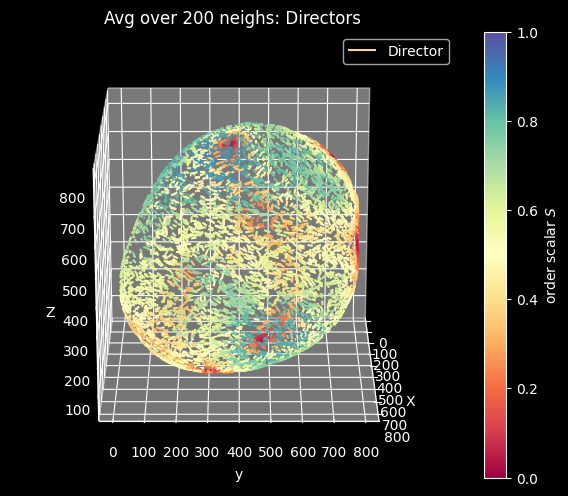

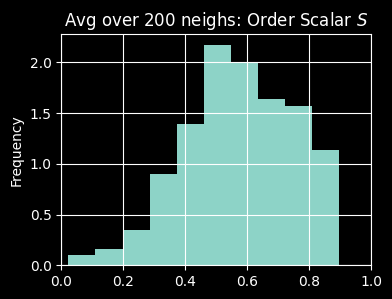

In [23]:
# ==== Tune Curved Nematic Analysis ====
k = 200
# ==== Tune Plotting parameters ====
plot_avg_dirs = False
vec_length = 20
vec_edge_width = vec_length / 6
plot2d_view = (20, 0)
renderfigsize = (6, 5)
histfigsize = (4, 3)
veccoords = directors_2dcurved[:, :3]
neigh_idxs = analysis.coord_search_neighbours(veccoords, k=k, n_process=8)
# ==== Visualise Averaging Patch ====
# visuals.view_neighbourhood(points=veccoords, intensities=np.ones(shape=(len(neigh_idxs))),
#                            neighbours=veccoords[neigh_idxs], mesh_size=1,
#                            sel_idx=np.random.choice(range(len(neigh_idxs))), pt_size=1,
#                            mesh_blending="translucent_no_depth")

# ==== Calculate Curved Nematic Order ====
num_avg_tan_nem_iters = 1
S_2dcurv_all, n_avg_2dcurv_all = analysis.avg_tan_nem_tens(t1_cov=tan_x, t2_cov=tan_y,
                                                           directors=directors_2dcurved,
                                                           neigh_idxs=neigh_idxs, num_iterations=num_avg_tan_nem_iters)
# Select Last Iteration Result
S_2dcurv = S_2dcurv_all[-1]
n_avg_2dcurv = n_avg_2dcurv_all[-1]

# ==== Save Curved Nematic Order ====
datahandler.save_array(S_2dcurv, name=f"S-order_2dcurved_k-{k}", header="S", folderpath=resdata_dir_layer)
datahandler.save_array(np.column_stack((veccoords, n_avg_2dcurv)), name=f"directors-avg_2dcurved_k-{k}",
                       header="x,y,z,vx,vy,vz", folderpath=resdata_dir_layer)

# ==== Plot Curved Nematic Order ====
directors_2dcurved_avg = directors_2dcurved.copy()
directors_2dcurved_avg[:, 3:] = n_avg_2dcurv
if plot_avg_dirs:
    print(">> Plotting average directions coloured by order S...")
    plot_vec_posdir = directors_2dcurved_avg.copy()
else:
    print(">> Plotting original directions coloured by order S...")
    plot_vec_posdir = directors_2dcurved.copy()
title_hist = f"Avg over {k} neighs: Order Scalar $S$"
if plot_avg_dirs:
    title_render = f"Avg over {k} neighs: Average Directors"
else:
    title_render = f"Avg over {k} neighs: Directors"
if plot_avg_dirs:
    savefig_render = os.path.join(resfig_dir_layer, f"avg-nematic_field_k-{k}.png")
else:
    savefig_render = os.path.join(resfig_dir_layer, f"nematic_field_k-{k}.png")
savefig_hist = os.path.join(resfig_dir_layer, f"hist_order_s_k-{k}.png")

visuals.plot_dir_field(directors=plot_vec_posdir, veclength=vec_length, view_init=plot2d_view, veccolor=S_2dcurv,
                       cmap_label="order scalar $S$", title=title_render, manual_vminmax=[0, 1],
                       savefig=savefig_render, figsize=renderfigsize, show_axes=False)
visuals.plot_hist(array=S_2dcurv, title=title_hist, savefig=savefig_hist,
                  figsize=histfigsize, xlim=[0, 1])

In [24]:
# ==== 3D Render Curved Nematic Order ====
vec_length = 20
vec_edge_width = 8
# visuals.view_3d_vector_field(vec_pos=plot_vec_posdir[:, :3], vec_dir=plot_vec_posdir[:, 3:],
#                              vec_colors=visuals.color_scalar(S_2dcurv, cmap="Spectral", manual_vminmax=[0, 1]),
#                              length=vec_length, pts_size=1,
#                              edge_width=vec_edge_width)

# visuals.view_3d_vector_field(vec_pos=plot_vec_posdir[:, :3], vec_dir=plot_vec_posdir[:, 3:],
#                              vec_colors=visuals.color_scalar(S_2dcurv, cmap="Spectral"),
#                              length=vec_length, edge_width=vec_edge_width,
#                              verts=sampl_mesh.vertices,
#                              verts_colors=visuals.color_scalar(analysis.normalise_range(proj_layer), cmap="Greens_r"))

visuals.view_colored_mesh_dir_field(mesh=sampl_mesh, directors=directors_2dcurved_avg,
                                    vec_colors=visuals.color_scalar(S_2dcurv),
                                    mesh_vert_colors=visuals.color_scalar(analysis.normalise_range(proj_layer),
                                                                          cmap="Greys"),
                                    vec_length=vec_length,
                                    vec_edge_width=vec_edge_width)

>> Rendering mesh and colored vertices...


### -- Load 2D+ Order --

>> Loaded .../directors-avg_2dcurved_k-200.csv | cols ['x', 'y', 'z', 'vx', 'vy', 'vz'] | shape (5968, 6)
>> Loaded .../S-order_2dcurved_k-200.csv | cols ['S'] | shape (5968,)


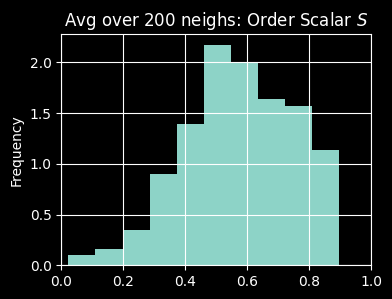

>> Rendering mesh and colored vertices...


In [32]:
# ==== Load 2D+ nematic order ====
k_load = 200
directors_2dcurved_avg = datahandler.load_array(f"directors-avg_2dcurved_k-{k_load}", folderpath=resdata_dir_layer)
S_2dcurv = datahandler.load_array(f"S-order_2dcurved_k-{k_load}", folderpath=resdata_dir_layer)
title_hist = f"Avg over {k_load} neighs: Order Scalar $S$"
visuals.plot_hist(S_2dcurv, title=title_hist, xlim=[0, 1])
visuals.view_colored_mesh_dir_field(mesh=sampl_mesh, directors=directors_2dcurved_avg,
                                    vec_colors=visuals.color_scalar(S_2dcurv),
                                    mesh_vert_colors=visuals.color_scalar(analysis.normalise_range(proj_layer),
                                                                          cmap="Greens_r"))

### |2.4| Identify Defect Location(s) + Geodesic Distance

/Users/andreadi/venv/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Distance matrix was created!
Found 4 defects!
>> Saved /Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/sphere_defects/data/full/defect-idxs.csv !
>> Plotting director field...


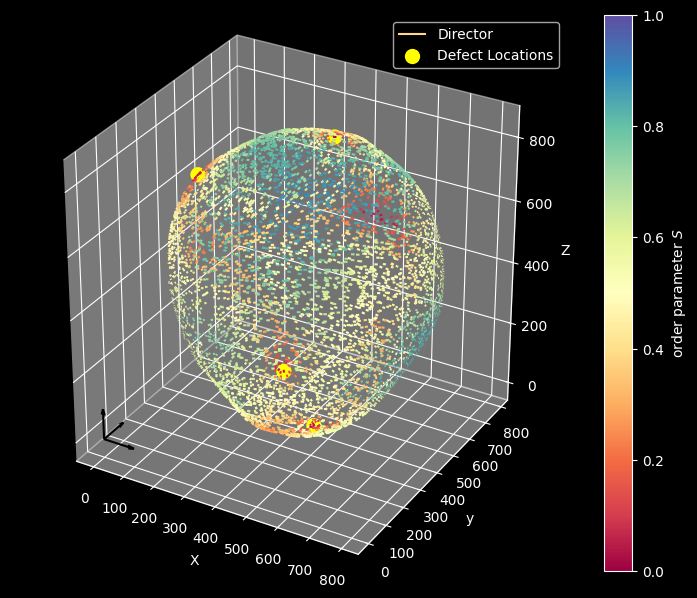

In [33]:
from joblib import Parallel, delayed

low_order_idxs = np.argsort(S_2dcurv)[:15]
target_num = 4
dist_cutoff = 30
defect_i_chosen = [0]

if target_num > 1:
    # Vectorized pair indices
    idx_pairs = np.array(np.triu_indices(len(low_order_idxs), k=1)).T

    # Parallel distance computation
    dist_vec = Parallel(n_jobs=-1)(
        delayed(analysis.geodesic_distmesh)(sampl_mesh, low_order_idxs[i], low_order_idxs[j], debug=False)
        for i, j in idx_pairs
    )

    # Fill symmetric matrix
    dist_matrix = np.full((len(low_order_idxs), len(low_order_idxs)), np.inf)
    dist_matrix[np.triu_indices(len(low_order_idxs), k=1)] = dist_vec
    dist_matrix += dist_matrix.T
    np.fill_diagonal(dist_matrix, 0)

    print("Distance matrix was created!")

    for _ in range(1, target_num):
        remaining = np.setdiff1d(np.arange(len(low_order_idxs)), defect_i_chosen)
        min_distances = np.min(dist_matrix[np.ix_(remaining, defect_i_chosen)], axis=1)
        next_choice = remaining[np.argmax(min_distances)]
        if np.all(dist_matrix[next_choice, defect_i_chosen] > dist_cutoff):
            defect_i_chosen.append(next_choice)

defect_idxs = [low_order_idxs[idx] for idx in defect_i_chosen]
print(f"Found {len(defect_idxs)} defects!")
datahandler.save_array(defect_idxs, name="defect-idxs", header="idx", folderpath=resdata_dir_layer)

# Plotting remains unchanged
visuals.plot_dir_field(directors=directors_2dcurved_avg, veclength=10, veccolor=S_2dcurv,
                       marker=directors_2dcurved_avg[:, :3][defect_idxs],
                       pt_label="Defect Locations", pt_color="yellow",
                       pt_alpha=1.0, cmap_label="order parameter $S$", manual_vminmax=[0, 1],
                       savefig=os.path.join(resfig_dir_layer, f"defect-locations.png"))

Geodesic distance between vertex #241023 and #142401: 445.7736766635007
>> Plotting director field...


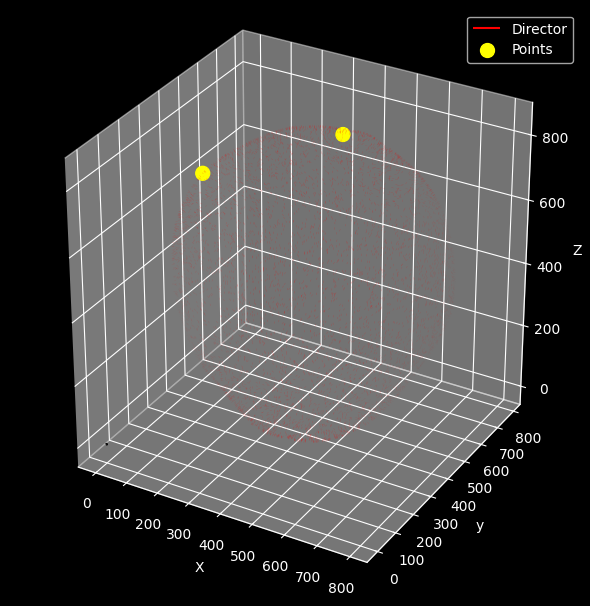

In [34]:
# ==== Calculate Geodesic Distance between Defects ====
defect_1_index = idxs_sel[defect_idxs[0]]
defect_2_index = idxs_sel[defect_idxs[1]]
dist = analysis.geodesic_distmesh(mesh=sampl_mesh, index1=defect_1_index, index2=defect_2_index, debug=True)
visuals.plot_dir_field(directors=directors_2dcurved_avg, veclength=0.3,
                       veccolor="red", marker=sampl_mesh.vertices[[defect_1_index, defect_2_index]],
                       pt_label="Points", pt_alpha=1.0)

In [35]:
from joblib import Parallel, delayed

# Convert defect indices to actual mesh indices
mesh_defect_idxs = [idxs_sel[i] for i in defect_idxs]
n_defects = len(mesh_defect_idxs)

# Get upper triangle pairs (i < j)
i_vals, j_vals = np.triu_indices(n_defects, k=1)


def safe_geodesic(i, j):
    try:
        dist = analysis.geodesic_distmesh(mesh=sampl_mesh,
                                          index1=mesh_defect_idxs[i],
                                          index2=mesh_defect_idxs[j],
                                          debug=False)
        return i, j, dist
    except Exception as e:
        print(f"Geodesic failed between defect {i} and {j}: {e}")
        return i, j, np.inf


# Parallel computation
results = Parallel(n_jobs=-1)(
    delayed(safe_geodesic)(i, j) for i, j in zip(i_vals, j_vals)
)


Distance Defect #0 -> #1 = 445.77 um
Distance Defect #0 -> #2 = 1092.75 um
Distance Defect #0 -> #3 = 850.23 um
Distance Defect #1 -> #2 = 989.67 um
Distance Defect #1 -> #3 = 807.88 um
Distance Defect #2 -> #3 = 284.90 um
>> Plotting director field...


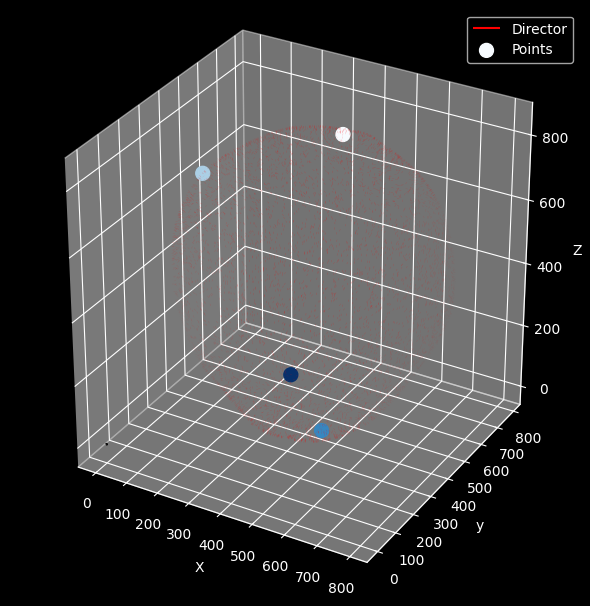

In [36]:
for i, j, dist in results:
    print(f"Distance Defect #{i} -> #{j} = {dist:.2f} {img_unit}")
visuals.plot_dir_field(directors=directors_2dcurved_avg, veclength=0.3,
                       veccolor="red", marker=sampl_mesh.vertices[idxs_sel[defect_idxs]],
                       pt_color=visuals.color_scalar(np.linspace(0, 1, len(defect_idxs)), "Blues"),
                       pt_label="Points", pt_alpha=1.0)

In [37]:
# visuals.view_colored_mesh(mesh=sampl_mesh, vert_colors=visuals.color_scalar(analysis.normalise_range(proj_layer), cmap="Greens_r"),
#                           markers=sampl_mesh.vertices[idxs_sel[defect_idxs]])  #, img=img_raw, scale=img_scale)
visuals.view_colored_mesh_dir_field(mesh=sampl_mesh, directors=directors_2dcurved_avg,
                                    vec_colors=visuals.color_scalar(S_2dcurv), marker_size=500,
                                    mesh_vert_colors=visuals.color_scalar(analysis.normalise_range(proj_layer),
                                                                          cmap="Greys"),
                                    markers=sampl_mesh.vertices[idxs_sel[defect_idxs]])


>> Rendering mesh and colored vertices...


In [38]:
visuals.view_colored_mesh_dir_field(mesh=sampl_mesh, directors=directors_2dcurved_avg,
                                    vec_colors=visuals.color_scalar(S_2dcurv), marker_size=100,
                                    mesh_vert_colors=visuals.color_scalar(analysis.normalise_range(proj_layer),
                                                                          cmap="Greys"),
                                    markers=sampl_mesh.vertices[idxs_sel[np.argsort(S_2dcurv)[:6]]])

>> Rendering mesh and colored vertices...


### |2.5| Topological Charge of Nematic Point Defects

In [39]:
# # ==== Calculate Gaussian Curvature for Topological Charge Analysis ====
gauss_exp = 1 / (np.ptp(sampl_mesh.vertices, axis=0).mean() / 2) ** 2
gauss_order_min, gauss_order_max = round(np.log10(gauss_exp)) - 1, round(np.log10(gauss_exp)) + 1
print(f"Gauss should be around {gauss_exp:.2e} (1/{img_unit}^2)")
gauss_crop_range = [0.1 * 10 ** gauss_order_min, 10 ** gauss_order_max]
gauss_crop_range = None
curv_charge_quick = analysis.curvature_by_srf_fit(mesh=sampl_mesh, k=20,
                                                  debug=True, gauss_crop_range=gauss_crop_range, num_sample=10000)
# Results given as curv_charge_quick = C_gauss, C_mean, Gauss_idxs, mean_idxs
gauss_curv_smooth = analysis.interpolate_on_mesh(mesh=sampl_mesh, value_idxs=curv_charge_quick[2],
                                                 values=curv_charge_quick[0], k=10)

Gauss should be around 6.54e-06 (1/um^2)
>> Calculating curvature for mesh with k=20 and for 10000/596867 vertices...
Gauss: AVG = 6.35757554962291e-06 | MIN = -4.507664001437561e-05 | MAX = 0.00018249035146678072 | None? = 0
Mean: AVG = 0.002568248700314369 | MIN = -0.002499940259793466 | MAX = 0.013889297945153083 | None? = 0
>> Interpolating 10000 values on mesh of 596867 vertices with k = 10...


>> Locally flattening coords ...
>> Calculating topological charge for 596867 directors...
>> Searching 5000 neighbours ...
-- surface integrals = [0.129 0.123 0.126 0.019]
-- line charge m = [-0.02762786908525159, -0.020802619641813, -0.019008590611548106, -0.0037823735908928207]
Charges calculated : [-0.007 -0.001  0.001 -0.001]
Total Charge: -0.008201488136206313
>> Plotting director field...


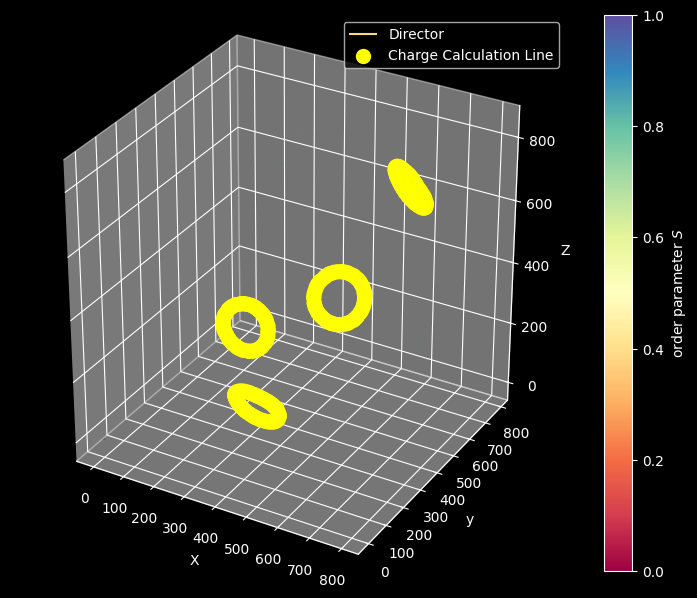

>> Plotting director field...


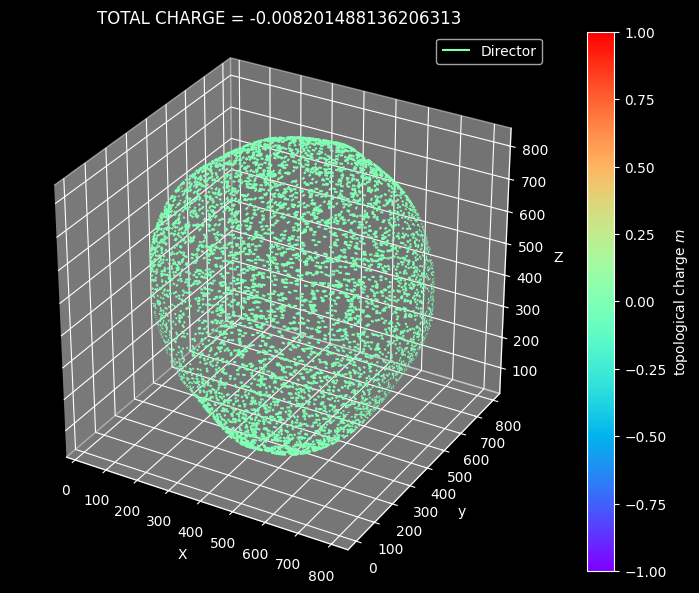

>> Saved /Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/sphere_defects/data/full/top-charge_2dcurved_k-5000.csv !


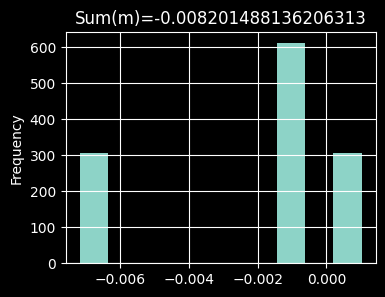

>> Plotting director field...


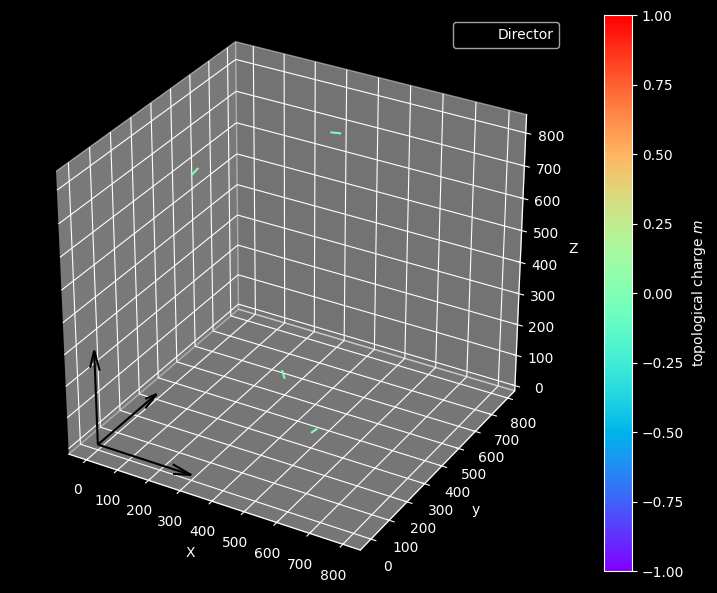

In [108]:
# ==== Calculate Curved Topological Charge ====
k_charge = len(sampl_mesh.vertices) // 2 - 1
# k_charge = len(sampl_mesh.vertices) // 9
k_charge = 5000
# defect_idxs = np.argsort(S_2dcurv)[:100]
charge_patch_idxs = analysis.coord_search_neighbours(sampl_mesh.vertices,
                                                     custom_probes=sampl_mesh.vertices[idxs_sel[defect_idxs]],
                                                     k=k_charge)
# charge_patch_idxs, _ = analysis.filter_valid_patches(sampl_mesh.vertices, charge_patch_idxs, factor=0.2)
charge_patch_idxs = analysis.unique_neighborhoods(charge_patch_idxs)
defect_idxs_calc = [np.argwhere(idxs_sel == i)[0][0] for i in charge_patch_idxs[:, 0]]

_, tan_x_all, tan_y_all = analysis.tan_proj(sampl_mesh.vertices[:, np.newaxis], sampl_mesh.vertex_normals)
# m_charge, calc_charge_loop_idxs = analysis.curved_nem_charge(mesh=sampl_mesh, directors=directors_2dcurved_avg,
#                                                              calc_idxs=defect_idxs_calc,
#                                                              director_indeces=idxs_sel,
#                                                              tan_x=tan_x_all, tan_y=tan_y_all,
#                                                              c_gauss=gauss_curv_smooth,
#                                                              loop_angle_precision=1, k_charge=k_charge, debug=True,
#                                                              correct_orientation=True)
m_charge, calc_charge_loop_idxs = analysis.curved_nem_charge(mesh=sampl_mesh, directors=directors_2dcurved_avg_interp,
                                                             calc_idxs=defect_idxs_calc,
                                                             director_indeces=np.arange(sampl_mesh.vertices.shape[0]),
                                                             tan_x=tan_x_all, tan_y=tan_y_all,
                                                             c_gauss=gauss_curv_smooth,
                                                             loop_angle_precision=1, k_charge=k_charge, debug=True,
                                                             correct_orientation=True)

visuals.plot_dir_field(directors=directors_2dcurved_avg, veclength=0.02, veccolor=S_2dcurv,
                       marker=np.vstack([sampl_mesh.vertices[i] for i in calc_charge_loop_idxs]),
                       pt_label="Charge Calculation Line",
                       pt_alpha=1.0, cmap_label="order parameter $S$", manual_vminmax=[0, 1])

m_charge_extended = np.full(len(sampl_mesh.vertices), 0.0)
m_charge_extended[analysis.coord_search_neighbours(sampl_mesh.vertices,
                                                   custom_probes=sampl_mesh.vertices[idxs_sel[defect_idxs_calc]],
                                                   k=k_charge,
                                                   debug=False)] = m_charge[:, np.newaxis]
m_charge_extended = m_charge_extended.ravel()
visuals.plot_dir_field(directors=directors_2dcurved_avg, veclength=10, veccolor=m_charge_extended[idxs_sel],
                       cmap="rainbow",
                       title=f"TOTAL CHARGE = {np.nansum(m_charge)}", cmap_label="topological charge $m$",
                       manual_vminmax=[-1, 1], show_axes=False)

# ==== Save Curved Topological Charge ====
datahandler.save_array(m_charge, name=f"top-charge_2dcurved_k-{k_charge}", header="m", folderpath=resdata_dir_layer)

# ==== Plot Curved Topological Charge ====
visuals.plot_hist(m_charge, title=f"Sum(m)={np.nansum(m_charge)}",
                  savefig=os.path.join(resfig_dir_layer, f"hist_top-charge_k-{k_charge}"))
plot_m_charge = np.full(directors_2dcurved_avg.shape[0], np.nan)
plot_m_charge[defect_idxs_calc] = m_charge
visuals.plot_dir_field(directors=directors_2dcurved_avg, veclength=30, veccolor=plot_m_charge, cmap="rainbow",
                       cmap_label="topological charge $m$", manual_vminmax=[-1, 1],
                       savefig=os.path.join(resfig_dir_layer, f"top-charge_k-{k_charge}"))

In [104]:
vxinterps = analysis.interpolate_on_mesh(mesh=sampl_mesh, value_idxs=idxs_sel, values=directors_2dcurved_avg[:, 3], k=2)
vyinterps = analysis.interpolate_on_mesh(mesh=sampl_mesh, value_idxs=idxs_sel, values=directors_2dcurved_avg[:, 4], k=2)
vzinterps = analysis.interpolate_on_mesh(mesh=sampl_mesh, value_idxs=idxs_sel, values=directors_2dcurved_avg[:, 5], k=2)
v_interp = np.column_stack((vxinterps, vyinterps, vzinterps))
tan_x, tan_y = analysis.create_tangential_basis(sampl_mesh.vertex_normals)
v_tx = np.einsum('ij,ij->i', v_interp, tan_x)  # scalar coeffs for tx
v_ty = np.einsum('ij,ij->i', v_interp, tan_y)  # scalar coeffs for ty

# Reconstruct tangent vector field
V_tangent = v_tx[:, None] * tan_x + v_ty[:, None] * tan_y
V_tangent /= np.linalg.norm(V_tangent, axis=1, keepdims=True)
directors_2dcurved_avg_interp = np.column_stack((sampl_mesh.vertices, V_tangent))

>> Interpolating 5968 values on mesh of 596867 vertices with k = 2...
>> Interpolating 5968 values on mesh of 596867 vertices with k = 2...
>> Interpolating 5968 values on mesh of 596867 vertices with k = 2...


In [105]:
visuals.view_3d_vector_field(directors_2dcurved_avg_interp[::100, :3], directors_2dcurved_avg_interp[::100, 3:],
                             vec_colors="red")

>> Rendering 3D vector field...


In [90]:
visuals.view_colored_mesh_dir_field(mesh=sampl_mesh, directors=directors_2dcurved_avg, mesh_shading="smooth",
                                    mesh_vert_colors="grey",
                                    vec_colors=visuals.color_scalar(m_charge_extended[idxs_sel], manual_vminmax=[-1, 1],
                                                                    cmap="rainbow"),
                                    markers=sampl_mesh.vertices[idxs_sel[defect_idxs_calc]], marker_size=400)

>> Rendering mesh and colored vertices...


### |2.6| Criss-Cross

In [40]:
# ==== Choose Layers for Criss-Cross Analysis ====
layer_name_1 = "inner"
layer_name_2 = "outer"
k_load = 200
inner_directors = datahandler.load_array(name=f"directors-avg_2dcurved_k-{k_load}",
                                         folderpath=os.path.join(resdata_dir, layer_name_1))
outer_directors = datahandler.load_array(name=f"directors-avg_2dcurved_k-{k_load}",
                                         folderpath=os.path.join(resdata_dir, layer_name_2))

# ==== Perform Criss-Cross Analysis ====
vec_near_1, vec_near_2 = (inner_directors, outer_directors) if len(inner_directors) >= len(outer_directors) else (
    outer_directors, inner_directors)

inter_layer_idxs = analysis.multi_coord_search_neighbours(verts_tree=vec_near_1[:, :3],
                                                          verts_query=vec_near_2[:, :3], k=1)
vec_near_1 = vec_near_1[inter_layer_idxs]

crisscross_mag = 1 - np.abs(np.sum(vec_near_1[:, 3:] * vec_near_2[:, 3:], axis=1) /
                            (np.linalg.norm(vec_near_1[:, 3:], axis=1) * np.linalg.norm(vec_near_2[:, 3:], axis=1)))
print(f"Average criss-cross strength: {np.average(crisscross_mag)}")

# ==== Perform Criss-Cross Analysis ====
datahandler.save_array(crisscross_mag, "crisscross_mag", header="strength", folderpath=resdata_dir)

# ==== Plot Criss-Cross Analysis ====
visuals.plot_hist(crisscross_mag, title="Criss-Cross Strength", xlim=[0, 1],
                  savefig=os.path.join(resfig_dir, f"hist_crisscross_mag"))

visuals.plot_dir_field(directors=vec_near_1, veclength=10, view_init=(20, 0),
                       veccolor=crisscross_mag,
                       cmap_label="Criss-Cross Strength", show_axes=False, manual_vminmax=[0, 1], cmap="jet",
                       savefig=os.path.join(resfig_dir, f"nematic-field_crisscross_mag"))


/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/sphere_defects/data/inner/directors-avg_2dcurved_k-200.csv does not exist, exiting...
/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/sphere_defects/data/outer/directors-avg_2dcurved_k-200.csv does not exist, exiting...


TypeError: object of type 'NoneType' has no len()

In [ ]:
# ==== Load Meshes ====
inner_mesh_smooth = datahandler.load_mesh(os.path.join(resdata_dir, "inner_mesh_smooth.ply"), recalc_normals=True,
                                          clean=True)
outer_mesh_smooth = datahandler.load_mesh(os.path.join(resdata_dir, "outer_mesh_smooth.ply"), recalc_normals=True,
                                          clean=True)
# ==== Load Projections ====
proj_layer_In = datahandler.load_array("intensities", folderpath=os.path.join(resdata_dir, "inner"))
proj_layer_Out = datahandler.load_array("intensities", folderpath=os.path.join(resdata_dir, "outer"))

In [ ]:
# ==== 3D Render ====
visuals.view_colored_verts_multiple(verts1=outer_mesh_smooth.vertices,
                                    colors1=visuals.color_scalar(analysis.normalise_range(proj_layer_Out),
                                                                 cmap="inferno"),
                                    verts2=inner_mesh_smooth.vertices,
                                    colors2=visuals.color_scalar(analysis.normalise_range(proj_layer_In),
                                                                 cmap="inferno"), ptsize=0.7)

In [ ]:
# ==== 3D Render Criss-Cross Analysis ====
vec_length = 10
vec_edge_width = vec_length / 6
# visuals.view_3d_vector_field_multiple(vec_pos=[vec_near_1[:, :3], vec_near_2[:, :3]],
#                                       vec_dir=[vec_near_1[:, 3:], vec_near_2[:, 3:]],
#                                       vec_colors=[
#                                           visuals.color_scalar(crisscross_mag, manual_vminmax=[0, 1], cmap="jet"),
#                                           ["grey" for i in range(len(vec_near_2))]],
#                                       vec_length=vec_length, edge_width=vec_edge_width,
#                                       verts=sampl_mesh.vertices,
#                                       verts_colors=visuals.color_scalar(analysis.normalise_range(proj_layer), cmap="Greens"))

visuals.view_3d_vector_field_multiple(vec_pos=[vec_near_1[:, :3], vec_near_2[:, :3]],
                                      vec_dir=[vec_near_1[:, 3:], vec_near_2[:, 3:]],
                                      vec_colors=[
                                          visuals.color_scalar(crisscross_mag, manual_vminmax=[0, 1], cmap="jet"),
                                          ["grey" for i in range(len(vec_near_2))]],
                                      vec_length=vec_length, edge_width=vec_edge_width, mesh=sampl_mesh,
                                      mesh_shading="none")

In [ ]:
visuals.view_colored_mesh_multiple(mesh_list=[inner_mesh_smooth, outer_mesh_smooth],
                                   vert_colors_list=[visuals.color_scalar(analysis.normalise_range(proj_layer_In),
                                                                          cmap="inferno"),
                                                     visuals.color_scalar(analysis.normalise_range(proj_layer_Out),
                                                                          cmap="inferno")])

## |3| 3D Bulk

### |3.1| Directors

In [ ]:
# ==== Extract 3D Directors ====
boxsize_target = 2
boxsize = analysis.rescale_val_xyz(boxsize_target, img_scale)
boxsize = tuple([int(boxsize[i]) for i in range(len(boxsize))])
boxsize = (boxsize_target, boxsize_target, boxsize_target)
print(f"boxsize {boxsize}")
orient3d_result = analysis.compute_3d_orientation(mode="fiber", img=img_raw.astype(np.float64),
                                                  sampling_box_size=boxsize,
                                                  onlydirec=True, upscale_vec=True)
x, y, z = np.meshgrid(
    np.arange(orient3d_result.shape[0]), np.arange(orient3d_result.shape[1]), np.arange(orient3d_result.shape[2]),
    indexing="ij"
)
coordinates = np.stack([x.ravel(), y.ravel(), z.ravel()], axis=1)
veccomponents = orient3d_result.reshape(-1, 3)
raw_directors_3d = np.hstack([coordinates, veccomponents])
print(f"{len(raw_directors_3d)} directors for a {orient3d_result.shape} vector field !")

### |3.2| Threshold Directors

In [ ]:
# ==== Threshold 3D Directors ====
img_thresh_mask = analysis.thresh_img(img=img_raw, thresh=0.4)
# img_thresh_mask = img_thresh.copy()
dir_coords = raw_directors_3d[:, :3].astype(int)
directors_3d = raw_directors_3d[img_thresh_mask[tuple(dir_coords.T)] != 0]
sampling_frequency = 2
directors_3d = directors_3d[::sampling_frequency]
directors_3d[:, :3] *= img_scale
datahandler.save_array(directors_3d, "directors_3d", header="x,y,z,vx,vy,vz", folderpath=resdata_dir)
print(f"Reduced to {len(directors_3d)} directors !")

# ==== Plot 3D Directors ====
# visuals.plot_dir_field(directors=directors_3d,
#                        veclength=1, figsize=(5, 5), view_init=(20, 20),
#                        savefig=os.path.join(resfig_dir, f"directors-3d"))

In [ ]:
# ==== 3D Render 3D Directors ====
visuals.view_3d_vector_field(vec_pos=directors_3d[:, :3], vec_dir=directors_3d[:, 3:],
                             vec_colors="red", length=10, edge_width=0.1, img=img_raw, scale=img_scale)

### -- Load Directors --

In [ ]:
# ==== Load 3D Directors ====
directors_3d = datahandler.load_array(name="directors_3d", folderpath=resdata_dir)

### |3.3| S order

In [ ]:
# ==== Calculate Nematic Order ====
k = 3 ** 3
idxs = analysis.coord_search_neighbours(directors_3d, k=k, n_process=10)
S_3d, n_avg_3d = analysis.avg_3d_nem_tens(directors=directors_3d, neigh_idxs=idxs)
# directors_3d[:, 3:] = n_avg_3d # [!] overwrites vector field [!]

# ==== Save Nematic Order ====
datahandler.save_array(S_3d, name=f"S-order_3d_k-{k}", header="S", folderpath=resdata_dir)
datahandler.save_array(np.column_stack((directors_3d[:, :3], n_avg_3d)), name=f"directors-avg_3d_k-{k}",
                       header="x,y,z,vx,vy,vz",
                       folderpath=resdata_dir)

# ==== Plot Nematic Order ====
# visuals.plot_dir_field(directors=directors_3d, veccolor=S_3d, cmap_label="order scalar $S$",
#                        veclength=10, figsize=(5, 5), view_init=(20, 20),
#                        savefig=os.path.join(resfig_dir, f"nematic-field-3d_k-{k}"))

# ==== 3D Render Neighbourhood for Nematic Order Analysis ====
# visuals.view_neighbourhood(points=directors_3d[:, :3], intensities=np.ones(shape=(len(idxs))),
#                            neighbours=directors_3d[:, :3][idxs], mesh_size=2,
#                            sel_idx=np.random.choice(range(len(idxs))), pt_size=2,
#                            mesh_blending="translucent_no_depth")

In [ ]:
# ==== 3D Render Nematic Order ====
vec_length = 5
vec_edge_width = vec_length / 6
freq = 1
plot_coords = directors_3d[:, :3][::freq]

# plot_vecs = directors_3d[:, 3:][::freq]
plot_vecs = n_avg_3d[::freq]

plot_colors = visuals.color_scalar(S_3d[::freq], manual_vminmax=[0, 1])
# plot_colors = visuals.color_scalar(
#     np.linalg.norm(plot_coords[:, :3] - np.mean(plot_coords[:, :3], axis=0, keepdims=True), axis=1))
visuals.view_3d_vector_field(vec_pos=plot_coords, vec_dir=plot_vecs,
                             vec_colors=plot_colors, length=vec_length, edge_width=vec_edge_width,
                             img=img_raw, scale=img_scale)

In [ ]:
# mask = ~np.all((plot_coords - np.mean(plot_coords, axis=0) > 0), axis=1)
mask = plot_coords[:, 0] > np.mean(plot_coords, axis=0)[0]
visuals.view_3d_vector_field(vec_pos=plot_coords[mask], vec_dir=plot_vecs[mask],
                             vec_colors=plot_colors[mask], length=vec_length, edge_width=vec_edge_width)

### |3.4| Topological Charge of Polar Point Defects

In [ ]:
img_extends = [img_dim[i] * img_scale[i] for i in range(len(img_dim))]
charge_sphere_pos_all = np.array(img_extends) // 2
charge_sphere_pos_all = directors_3d[:, :3][np.argsort(S_3d)[:4]]
charge_sphere_radius = 20
charge_sphere_all = [trimesh.creation.icosphere(radius=charge_sphere_radius, subdivisions=5).apply_translation(
    pos_sphere) for pos_sphere in charge_sphere_pos_all]

visuals.plot_img(img=img_raw, scale=img_scale, unit=img_unit,
                 meshes=charge_sphere_all, mesh_alpha=1)

In [ ]:
enclosed_3d_charge = analysis.top_charge_bulk(vec_field=directors_3d, measure_centers=charge_sphere_pos_all,
                                              measure_radii=charge_sphere_radius, debug=False)
print(f"Found {enclosed_3d_charge}")
enclosed_3d_charge = np.abs(enclosed_3d_charge)  # [!] Take absolute value for nematics [!]
visuals.plot_dir_field(directors_3d, veclength=1, veccolor=np.ones(len(directors_3d)) * enclosed_3d_charge[0],
                       cmap="rainbow", cmap_label="Point Defect Charge", manual_vminmax=[-1, 1],
                       title=f"Enclosed 3D Charge: {enclosed_3d_charge[0]} !")

In [ ]:
charge3dkeepmask = (~np.isnan(enclosed_3d_charge)) & (enclosed_3d_charge > 0.5)
plot_enclosed_3d_charge = enclosed_3d_charge[charge3dkeepmask]
plot_charge_sphere_pos_all = charge_sphere_pos_all[charge3dkeepmask]
visuals.plot_hist(plot_enclosed_3d_charge, title="Point Defect Charges")

In [ ]:
visuals.view_3d_vector_field(vec_pos=directors_3d[:, :3], vec_dir=directors_3d[:, 3:],
                             vec_colors=visuals.color_scalar(S_3d, manual_vminmax=[-1, 1]), length=20,
                             img=img_raw, scale=img_scale, verts=plot_charge_sphere_pos_all,
                             verts_colors=visuals.color_scalar(plot_enclosed_3d_charge, manual_vminmax=[0, 1],
                                                               cmap="hot"),
                             pts_size=10)